# Анализ данных ВКР: деградация ММГ и ЧС в Якутии

## Источники данных (ВНИИГМИ-МЦД)

| Источник | Формат | Папка |
|---|---|---|
| Температура почвы (`idata=4`) | IIIII.txt, суточные, глубины 2–320 см, значения ×10 | `data/soil/` |
| Снежный покров (`idata=7`) | IIIII.txt, суточные, высота снега + степень покрытия | `data/snow/` |
| Темп. воздуха + осадки (`idata=5`, TTTR) | IIIII.txt, суточные, Tmin/Tmean/Tmax/R | `data/air/` |
| Уровень воды (Лена, Якутск) | CSV | `data/water_level_lena.csv` |
| СТС/ALT (CALM) | Excel | `data/calm_yakutia.xlsx` |
| ЧС (МЧС) | CSV | `data/mchs_events.csv` |

import sys
print(sys.version)

!python3.11 --version

!python3.11 -m pip install "xlrd>=2.0.1"

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import re
from datetime import datetime
import matplotlib.patches as mpatches

In [72]:
warnings.filterwarnings('ignore')

DATA_DIR = Path('data')
RESULTS_DIR = Path('результаты')
for d in ['soil', 'snow', 'air', 'hydro']:
    (DATA_DIR / d).mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ─── Метеостанции (финальный набор: 4 профильных + 2 фоновых) ──────────────
# Коды — идентификаторы ВНИИГМИ-МЦД (совпадают с WMO, кроме Олёкминска:
# в файлах ВНИИГМИ он идёт как 24944, тогда как WMO-код — 24641)
YAKUTIA_STATIONS = {
    30230: 'Киренск',    # приоритет 1 — верхний триггер оттепели/вскрытия
    24944: 'Олёкминск',  # приоритет 1 — промежуточный узел (WMO 24641, ID в файлах 24944)
    24959: 'Якутск',     # приоритет 1 — главная целевая зона риска
    24343: 'Жиганск',    # приоритет 1 — контроль ниже по течению
    24266: 'Верхоянск',  # приоритет 2 — фоновая контрольная (р. Яна)
    24688: 'Оймякон',    # приоритет 2 — фоновая экстремально-континентальная
}

STATION_PRIORITY = {30230: 1, 24944: 1, 24959: 1, 24343: 1, 24266: 2, 24688: 2}

# Профиль вдоль Лены от верховий вниз — порядок важен для расчёта лагов
LENA_PROFILE = [30230, 24944, 24959, 24343]

# ─── Гидропосты (9 рабочих) ────────────────────────────────────────────────
HYDRO_POSTS = {
    'Киренск':   1, 'Витим':    1, 'Ленск':    1,
    'Олёкминск': 1, 'Покровск': 1, 'Якутск':   1,
    'Табага':    1, 'Сангар':   2, 'Жиганск':  2,
}

# Имена файлов в data/hydro/ (формат allrivers.info: lena-<translit>.csv)
HYDRO_FILES = {
    'Киренск':   'lena-kirensk',
    'Витим':     'lena-vitim',
    'Ленск':     'lena-lensk',
    'Олёкминск': 'lena-olekminsk',
    'Покровск':  'lena-pokrovsk',
    'Якутск':    'lena-yakutsk',
    'Табага':    'lena-tabaga',
    'Сангар':    'lena-sangar',
    'Жиганск':   'lena-zhigansk',
}


def find_wr_file(data_dir: Path) -> Path | None:
    """Ищет файл wr*.txt внутри подпапки (структура архива ВНИИГМИ-МЦД)."""
    for subdir in sorted(data_dir.iterdir()):
        if subdir.is_dir():
            for f in subdir.glob('wr*.txt'):
                return f
    return None


print('Инициализация завершена')
print(f'Метеостанций: {len(YAKUTIA_STATIONS)} | Профиль Лены: '
      f'{" → ".join(YAKUTIA_STATIONS[s] for s in LENA_PROFILE)}')
print(f'Гидропостов:  {len(HYDRO_POSTS)} '
      f'({sum(1 for p in HYDRO_POSTS.values() if p == 1)} обязательных)')



Инициализация завершена
Метеостанций: 6 | Профиль Лены: Киренск → Олёкминск → Якутск → Жиганск
Гидропостов:  9 (7 обязательных)


## 1. Температура почвы

**Формат файла** (`IIIII.txt`):
```
SSSSS YYYY MM DD  T02 Q  T05 Q  T10 Q  T15 Q  T20 Q  T40 Q  T60 Q  T80 Q T120 Q T160 Q T240 Q T320 Q
```
- Значения температуры умножены на 10 (−18 = −1.8°C)
- `9999` = отсутствие данных
- Признаки качества: 0=достоверно, 1–4=ошибка, 5–7=сомнительно, 9=нет данных

In [73]:
SOIL_DEPTHS = [2, 5, 10, 15, 20, 40, 60, 80, 120, 160, 240, 320]

def parse_soil_file(filepath: Path) -> pd.DataFrame:
    rows = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                station_id = int(parts[0])
                year, month, day = int(parts[1]), int(parts[2]), int(parts[3])
                date = pd.Timestamp(year=year, month=month, day=day)
            except (ValueError, IndexError):
                continue

            temp_data = {}
            idx = 4
            for depth in SOIL_DEPTHS:
                if idx + 1 >= len(parts):
                    break
                try:
                    val = float(parts[idx])
                    qflag = float(parts[idx + 1])
                    if val == 999.9 or qflag in (1, 2, 3, 4, 8):
                        temp_data[f't{depth}cm'] = np.nan
                    else:
                        temp_data[f't{depth}cm'] = val / 10.0
                except (ValueError, IndexError):
                    temp_data[f't{depth}cm'] = np.nan
                idx += 2

            row = {'date': date, 'station_id': station_id,
                   'station_name': YAKUTIA_STATIONS.get(station_id, str(station_id))}
            row.update(temp_data)
            rows.append(row)

    return pd.DataFrame(rows)


soil_dir = DATA_DIR / 'soil'
wr_soil = find_wr_file(soil_dir)

if wr_soil:
    print(f'Файл данных: {wr_soil}')
    df_soil = parse_soil_file(wr_soil)
    # Оставляем только нужные станции
    df_soil = df_soil[df_soil['station_id'].isin(YAKUTIA_STATIONS)]
    print(f'Итого: {len(df_soil)} строк, станции: {df_soil["station_name"].unique().tolist()}')
    print(f'Период: {df_soil["date"].min()} — {df_soil["date"].max()}')
    print(df_soil.tail())
else:
    print('Файл не найден. Распакуйте архив idata=4 в папку data/soil/')
    print('Ожидается структура: data/soil/wr.../wr....txt')
    df_soil = pd.DataFrame()

Файл данных: data/soil/wr373144a3/wr373144a3.txt
Итого: 134050 строк, станции: ['Верхоянск', 'Жиганск', 'Оймякон', 'Олёкминск', 'Якутск', 'Киренск']
Период: 1963-01-01 00:00:00 — 2024-12-31 00:00:00
             date  station_id station_name  t2cm  t5cm  t10cm  t15cm  t20cm  \
134045 2023-12-27       30230      Киренск   NaN   NaN    NaN    NaN  -0.64   
134046 2023-12-28       30230      Киренск   NaN   NaN    NaN    NaN  -0.64   
134047 2023-12-29       30230      Киренск   NaN   NaN    NaN    NaN  -0.62   
134048 2023-12-30       30230      Киренск   NaN   NaN    NaN    NaN  -0.58   
134049 2023-12-31       30230      Киренск   NaN   NaN    NaN    NaN  -0.56   

        t40cm  t60cm  t80cm  t120cm  t160cm  t240cm  t320cm  
134045  -0.67    NaN  -0.44     NaN    0.04     NaN    0.42  
134046  -0.65    NaN  -0.43     NaN    0.04     NaN    0.42  
134047  -0.61    NaN  -0.42     NaN    0.03     NaN    0.41  
134048  -0.58    NaN  -0.42     NaN    0.03     NaN    0.41  
134049  -0.55   

In [74]:
# Фильтр периода анализа: 2008–2023
START_YEAR, END_YEAR = 2008, 2023

if not df_soil.empty and 'date' in df_soil.columns:
    before = len(df_soil)
    df_soil['date'] = pd.to_datetime(df_soil['date'], errors='coerce')
    df_soil = df_soil[df_soil['date'].dt.year.between(START_YEAR, END_YEAR)].copy()
    print(f'Температура почвы: оставлено {len(df_soil)} из {before} строк за {START_YEAR}–{END_YEAR} гг.')
    if not df_soil.empty:
        print(f'Период после фильтра: {df_soil["date"].min().date()} — {df_soil["date"].max().date()}')


Температура почвы: оставлено 35064 из 134050 строк за 2008–2023 гг.
Период после фильтра: 2008-01-01 — 2023-12-31


## 2. Температура воздуха и осадки (TTTR)

**Формат строки:**
```
SSSSS YYYY MM DD TFLAG TMIN QTMIN TMEAN QTMEAN TMAX QTMAX R CR
20674 2001 12 27 0 -23.2 0 -19.7 0 -17.3 0 8.0 0 0
```
- TMIN, TMEAN, TMAX в °C с точностью 0.1
- R — суточные осадки, мм
- TFLAG=1 означает нарушение соотношений между Tmin/Tmean/Tmax

In [75]:
def parse_air_file(filepath: Path) -> pd.DataFrame:
    """
    Формат ВНИИГМИ-МЦД idata=5 (TTTR), фиксированная ширина:
    pos 0-4:   station  pos 6-9: year  pos 10-12: month  pos 13-15: day
    pos 17:    TFLAG (0=ok, 9=at least one flag)
    pos 18-23: Tmin   pos 25: Tmin_Q
    pos 26-31: Tmean  pos 33: Tmean_Q
    pos 34-39: Tmax   pos 41: Tmax_Q
    pos 42-47: precip
    Пустое поле = NaN; Q='9' = нет измерения (NaN).
    """
    rows = []

    def fv(s, qflag='0'):
        s = s.strip()
        if not s or qflag.strip() == '9':
            return np.nan
        try:
            f = float(s)
            return np.nan if abs(f) >= 999 else f
        except ValueError:
            return np.nan

    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if len(line) < 17:
                continue
            try:
                station_id = int(line[0:5])
                year  = int(line[6:10])
                month = int(line[10:13])
                day   = int(line[13:16])
            except (ValueError, IndexError):
                continue

            tmin_q  = line[25] if len(line) > 25 else '9'
            tmean_q = line[33] if len(line) > 33 else '9'
            tmax_q  = line[41] if len(line) > 41 else '9'

            tmin   = fv(line[18:24], tmin_q)  if len(line) > 23 else np.nan
            tmean  = fv(line[26:32], tmean_q) if len(line) > 31 else np.nan
            tmax   = fv(line[34:40], tmax_q)  if len(line) > 39 else np.nan
            precip = fv(line[42:48])           if len(line) > 47 else np.nan

            try:
                date = pd.Timestamp(year=year, month=month, day=day)
            except (ValueError, OverflowError):
                continue

            rows.append({
                'date': date, 'station_id': station_id,
                'tmin': tmin, 'tmean': tmean, 'tmax': tmax, 'precip_mm': precip
            })

    return pd.DataFrame(rows)


air_dir = DATA_DIR / 'air'
wr_air = find_wr_file(air_dir)

if wr_air:
    print(f'Файл данных: {wr_air}')
    df_air = parse_air_file(wr_air)
    df_air = df_air[df_air['station_id'].isin(YAKUTIA_STATIONS)]
    df_air['station_name'] = df_air['station_id'].map(YAKUTIA_STATIONS)
    print(f'Итого: {len(df_air)} строк, станции: {df_air["station_name"].unique().tolist()}')
    print(f'Период: {df_air["date"].min()} — {df_air["date"].max()}')
    print(f'Tmean  заполнено: {df_air["tmean"].notna().sum()} / {len(df_air)}')
    print(f'Tmin   заполнено: {df_air["tmin"].notna().sum()} / {len(df_air)}')
    print(f'Precip заполнено: {df_air["precip_mm"].notna().sum()} / {len(df_air)}')
    print(df_air[df_air['tmean'].notna()].tail())
else:
    print('Файл не найден. Распакуйте архив idata=5 в папку data/air/')
    df_air = pd.DataFrame()


Файл данных: data/air/wr373144a2/wr373144a2.txt
Итого: 266265 строк, станции: ['Верхоянск', 'Жиганск', 'Оймякон', 'Олёкминск', 'Якутск', 'Киренск']
Период: 1882-01-01 00:00:00 — 2025-12-31 00:00:00
Tmean  заполнено: 249867 / 266265
Tmin   заполнено: 242310 / 266265
Precip заполнено: 249543 / 266265
             date  station_id  tmin  tmean  tmax  precip_mm station_name
266260 2024-12-27       30230 -13.4  -12.0 -10.3        3.2      Киренск
266261 2024-12-28       30230 -13.2  -10.9  -9.7        0.6      Киренск
266262 2024-12-29       30230 -14.6  -10.5  -8.8        3.7      Киренск
266263 2024-12-30       30230 -12.7   -8.7  -6.7        1.1      Киренск
266264 2024-12-31       30230 -11.4   -9.6  -7.7        0.8      Киренск


In [76]:
# Фильтр периода анализа: 2008–2023
START_YEAR, END_YEAR = 2007, 2023

if not df_air.empty and 'date' in df_air.columns:
    before = len(df_air)
    df_air['date'] = pd.to_datetime(df_air['date'], errors='coerce')
    df_air = df_air[df_air['date'].dt.year.between(START_YEAR, END_YEAR)].copy()
    print(f'Температура воздуха и осадки: оставлено {len(df_air)} из {before} строк за {START_YEAR}–{END_YEAR} гг.')
    if not df_air.empty:
        print(f'Период после фильтра: {df_air["date"].min().date()} — {df_air["date"].max().date()}')


Температура воздуха и осадки: оставлено 37254 из 266265 строк за 2007–2023 гг.
Период после фильтра: 2007-01-01 — 2023-12-31


## 3. Снежный покров

**Формат строки (позиции):**
```
SSSSS YYYY MM DD  HHHH SS Q1 Q2 Q3
позиции: 1-5  7-10 12-13 15-16  18-21 23-24 26 28 30
```
- H: высота снега в см (9999 = нет данных)
- S: степень покрытия 0–10 (99 = нет)
- Q1=0: данные верны; Q1=1: нет снега; Q1=3: снег < 0.5 см

In [77]:
def parse_snow_file(filepath: Path) -> pd.DataFrame:
    rows = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if len(line) < 26:
                continue
            try:
                station_id = int(line[0:5])
                year  = int(line[6:10])
                month = int(line[11:13])
                day   = int(line[14:16])
                date  = pd.Timestamp(year=year, month=month, day=day)

                h_raw = line[17:21].strip()
                snow_cm = np.nan if h_raw in ('9999', '') else float(h_raw)

                s_raw = line[22:24].strip() if len(line) >= 24 else '99'
                coverage = np.nan if s_raw in ('99', '') else float(s_raw)

                q1 = int(line[25]) if len(line) > 25 and line[25].strip() else 9
                if q1 == 1:
                    snow_cm = 0.0

                rows.append({
                    'date': date, 'station_id': station_id,
                    'snow_depth_cm': snow_cm,
                    'snow_coverage_10': coverage,
                    'q1': q1
                })
            except (ValueError, IndexError):
                continue

    return pd.DataFrame(rows)


snow_dir = DATA_DIR / 'snow'
wr_snow = find_wr_file(snow_dir)

if wr_snow:
    print(f'Файл данных: {wr_snow}')
    df_snow = parse_snow_file(wr_snow)
    df_snow = df_snow[df_snow['station_id'].isin(YAKUTIA_STATIONS)]
    df_snow['station_name'] = df_snow['station_id'].map(YAKUTIA_STATIONS)
    print(f'Итого: {len(df_snow)} строк, станции: {df_snow["station_name"].unique().tolist()}')
    print(df_snow.tail())
else:
    print('Файл не найден. Распакуйте архив idata=7 в папку data/snow/')
    print('Ожидается структура: data/snow/wr.../wr....txt')
    df_snow = pd.DataFrame()

Файл данных: data/snow/wr373144a5/wr373144a5.txt
Итого: 266265 строк, станции: ['Верхоянск', 'Жиганск', 'Оймякон', 'Олёкминск', 'Якутск', 'Киренск']
             date  station_id  snow_depth_cm  snow_coverage_10  q1  \
266260 2024-12-27       30230           35.0              10.0   0   
266261 2024-12-28       30230           35.0              10.0   0   
266262 2024-12-29       30230           39.0              10.0   0   
266263 2024-12-30       30230           39.0              10.0   0   
266264 2024-12-31       30230           39.0              10.0   0   

       station_name  
266260      Киренск  
266261      Киренск  
266262      Киренск  
266263      Киренск  
266264      Киренск  


In [78]:
# Фильтр периода анализа: 2007–2023
START_YEAR, END_YEAR = 2007, 2023

if not df_snow.empty and 'date' in df_snow.columns:
    before = len(df_snow)
    df_snow['date'] = pd.to_datetime(df_snow['date'], errors='coerce')
    df_snow = df_snow[df_snow['date'].dt.year.between(START_YEAR, END_YEAR)].copy()
    print(f'Снежный покров: оставлено {len(df_snow)} из {before} строк за {START_YEAR}–{END_YEAR} гг.')
    if not df_snow.empty:
        print(f'Период после фильтра: {df_snow["date"].min().date()} — {df_snow["date"].max().date()}')


Снежный покров: оставлено 37254 из 266265 строк за 2007–2023 гг.
Период после фильтра: 2007-01-01 — 2023-12-31


## 4. Уровень воды — гидропосты (9 постов по профилю Лены)

Профиль: Киренск → Витим → Ленск → Олёкминск → Покровск → Якутск → Табага → Сангар → Жиганск

Источник: [allrivers.info](https://allrivers.info/), формат CSV с разделителем «;».  
Для каждого поста файл размещается в `data/hydro/<name>.csv`.  
До загрузки новых файлов `data/water_level_lena.csv` принимается как данные по Якутску (обратная совместимость).


In [79]:
def _read_hydro_csv(path: Path, post_name: str) -> pd.DataFrame:
    """Читает файл гидропоста (allrivers.info, разделитель ; или ,)."""
    for sep in (';', ','):
        try:
            df = pd.read_csv(path, sep=sep)
            if df.shape[1] < 2:
                continue
            date_col  = next((c for c in df.columns
                              if 'date' in c.lower() or 'дат' in c.lower()), df.columns[0])
            level_col = next((c for c in df.columns
                              if any(k in c.lower() for k in ('value', 'уров', 'level'))),
                             df.columns[1])
            df = df.rename(columns={date_col: 'date', level_col: 'level_cm'})
            df['date']     = pd.to_datetime(df['date'], errors='coerce')
            df['level_cm'] = pd.to_numeric(df['level_cm'], errors='coerce')
            df['post']     = post_name
            df['year']     = df['date'].dt.year
            df['month']    = df['date'].dt.month
            return df[['date', 'year', 'month', 'post', 'level_cm']].dropna(subset=['date'])
        except Exception:
            continue
    return pd.DataFrame()


hydro_frames = []

for post_name, priority in HYDRO_POSTS.items():
    # Ищем файл по маппингу имён (lena-<translit>.csv)
    stem = HYDRO_FILES.get(post_name, post_name)
    fp = DATA_DIR / 'hydro' / f'{stem}.csv'
    if fp.exists():
        df_p = _read_hydro_csv(fp, post_name)
        if not df_p.empty:
            hydro_frames.append(df_p)
            prio_mark = '●' if priority == 1 else '○'
            print(f'  {prio_mark} {post_name}: {len(df_p)} записей, '
                  f'{df_p["date"].min().date()} – {df_p["date"].max().date()}')
        else:
            print(f'  {post_name}: файл есть ({fp.name}), но не удалось распарсить')
    else:
        print(f'  {post_name}: нет файла → {fp}')

if hydro_frames:
    df_water = pd.concat(hydro_frames, ignore_index=True).drop_duplicates(['date', 'post'])
    loaded = df_water['post'].nunique()
    print(f'\nЗагружено гидропостов: {loaded} / {len(HYDRO_POSTS)}')
else:
    print('\nНет данных ни по одному гидропосту')
    df_water = pd.DataFrame()


  ● Киренск: 6679 записей, 2001-10-12 – 2024-05-13
  ● Витим: 7258 записей, 2001-01-11 – 2026-05-16
  ● Ленск: 7191 записей, 2001-01-11 – 2026-05-16
  ● Олёкминск: 7016 записей, 2001-01-11 – 2026-05-16
  ● Покровск: 6867 записей, 2001-01-11 – 2026-05-16
  ● Якутск: 6930 записей, 2001-01-11 – 2026-05-15
  ● Табага: 6939 записей, 2001-01-11 – 2026-05-16
  ○ Сангар: 6834 записей, 2001-01-11 – 2026-05-16
  ○ Жиганск: 6679 записей, 2001-01-11 – 2026-05-16

Загружено гидропостов: 9 / 9


In [80]:
# Фильтр периода анализа: 2008–2023
START_YEAR, END_YEAR = 2008, 2023

if not df_water.empty and 'date' in df_water.columns:
    before = len(df_water)
    df_water['date'] = pd.to_datetime(df_water['date'], errors='coerce')
    df_water = df_water[df_water['date'].dt.year.between(START_YEAR, END_YEAR)].copy()
    df_water['year'] = df_water['date'].dt.year
    df_water['month'] = df_water['date'].dt.month
    print(f'Уровень воды: оставлено {len(df_water)} из {before} строк за {START_YEAR}–{END_YEAR} гг.')
    if not df_water.empty:
        print(f'Период после фильтра: {df_water["date"].min().date()} — {df_water["date"].max().date()}')


Уровень воды: оставлено 47165 из 62393 строк за 2008–2023 гг.
Период после фильтра: 2008-01-01 — 2023-12-31


## 5. Анализ уровня воды в реках

После загрузки `df_water` анализируем не только наличие рядов, но и гидрологические характеристики по каждому посту:

- годовой и весенний максимум уровня воды;
- дату весеннего пика и лаг пика относительно Якутска;
- скорость подъёма уровня за 7 дней;
- число дней выше локального P90/P95 для поста;
- аномальные годы по z-score;
- синхронность постов по корреляции месячных уровней.

Это позволяет связать гидрологическую волну с оттепелью, заторами и риском подтопления.



In [81]:
# ── Анализ уровня воды по гидропостам Лены (обновлённый) ─────────────────

SPRING_MONTHS = [4, 5, 6]
ROLL_DAYS = 7
HIGH_WATER_QUANTILES = [0.90, 0.95]
REF_POST = 'Якутск'

# Если есть точные высоты постов — задай их здесь (м, БС или принятая система).
# Тогда ВСЕ таблицы/графики будут строго в порядке убывания высоты.
# Пример (замени на свои значения):
# HYDRO_POST_ELEV_M = {
#     'Киренск': 999.0,
#     'Витим': 950.0,
#     'Ленск': 900.0,
#     'Олёкминск': 850.0,
#     'Покровск': 820.0,
#     'Якутск': 800.0,
#     'Табага': 790.0,
#     'Сангар': 760.0,
#     'Жиганск': 730.0
# }

# Фолбэк-порядок по профилю Лены (если словарь высот не задан)
DEFAULT_HYDRO_ORDER = [
    'Киренск', 'Витим', 'Ленск', 'Олёкминск', 'Покровск',
    'Якутск', 'Табага', 'Сангар', 'Жиганск'
]

def _get_post_order(posts_in_data):
    """Возвращает порядок постов: по убыванию высоты (если есть словарь), иначе фолбэк."""
    if 'HYDRO_POST_ELEV_M' in globals() and isinstance(HYDRO_POST_ELEV_M, dict) and len(HYDRO_POST_ELEV_M) > 0:
        ordered = sorted(HYDRO_POST_ELEV_M, key=HYDRO_POST_ELEV_M.get, reverse=True)
    else:
        ordered = [p for p in DEFAULT_HYDRO_ORDER]
    # Добавляем посты, которых нет в списке, в конец (чтобы не терять данные)
    for p in posts_in_data:
        if p not in ordered:
            ordered.append(p)
    return ordered

def _prepare_water_level(df: pd.DataFrame) -> tuple[pd.DataFrame, list]:
    """Нормализует таблицу уровня воды: date/post/level_cm/year/month/doy + порядок постов."""
    if df is None or df.empty:
        cols = ['date', 'post', 'level_cm', 'year', 'month', 'doy']
        return pd.DataFrame(columns=cols), []
    water = df.copy()
    water['date'] = pd.to_datetime(water['date'], errors='coerce')
    water['level_cm'] = pd.to_numeric(water['level_cm'], errors='coerce')
    water['post'] = water['post'].astype(str).str.strip()

    water = water.dropna(subset=['date', 'post', 'level_cm']).copy()

    post_order = _get_post_order(water['post'].unique())
    water['post'] = pd.Categorical(water['post'], categories=post_order, ordered=True)

    water = water.sort_values(['post', 'date'])
    water['year'] = water['date'].dt.year
    water['month'] = water['date'].dt.month
    water['doy'] = water['date'].dt.dayofyear
    return water, post_order

def _annual_water_features(water: pd.DataFrame) -> pd.DataFrame:
    """Считает годовые признаки уровня воды по каждому гидропосту."""
    rows = []
    if water.empty:
        return pd.DataFrame()

    q_by_post = (water.groupby('post', observed=True)['level_cm']
                 .quantile(HIGH_WATER_QUANTILES)
                 .unstack()
                 .rename(columns={0.90: 'p90_level_cm', 0.95: 'p95_level_cm'}))

    for (post, year), g in water.groupby(['post', 'year'], observed=True):
        g = g.sort_values('date').copy()
        spring = g[g['month'].isin(SPRING_MONTHS)].copy()
        if g.empty:
            continue

        annual_peak_idx = g['level_cm'].idxmax()
        annual_peak_date = g.loc[annual_peak_idx, 'date']
        annual_peak = float(g.loc[annual_peak_idx, 'level_cm'])

        if spring.empty:
            spring_peak = np.nan
            spring_peak_date = pd.NaT
            spring_min = np.nan
            spring_amp = np.nan
            max_rise_7d = np.nan
            max_fall_7d = np.nan
            rise_start_date = pd.NaT
            days_from_rise_to_peak = np.nan
        else:
            spring_peak_idx = spring['level_cm'].idxmax()
            spring_peak_date = spring.loc[spring_peak_idx, 'date']
            spring_peak = float(spring.loc[spring_peak_idx, 'level_cm'])
            spring_min = float(spring['level_cm'].min())
            spring_amp = spring_peak - spring_min

            spring['diff_7d'] = spring['level_cm'].diff(ROLL_DAYS)
            spring['rate_7d_cm_day'] = spring['diff_7d'] / ROLL_DAYS

            max_rise_7d = float(spring['rate_7d_cm_day'].max()) if spring['rate_7d_cm_day'].notna().any() else np.nan
            max_fall_7d = float(spring['rate_7d_cm_day'].min()) if spring['rate_7d_cm_day'].notna().any() else np.nan

            # Дата начала подъёма: прирост за 7 дней >= max(20 см, 25% весенней амплитуды)
            rise_threshold = max(20.0, 0.25 * spring_amp) if pd.notna(spring_amp) else 20.0
            candidates = spring[spring['diff_7d'] >= rise_threshold]
            rise_start_date = candidates['date'].iloc[0] if not candidates.empty else pd.NaT

            days_from_rise_to_peak = (
                (spring_peak_date - rise_start_date).days
                if pd.notna(rise_start_date) and pd.notna(spring_peak_date)
                else np.nan
            )

        p90 = q_by_post.loc[post, 'p90_level_cm'] if post in q_by_post.index else np.nan
        p95 = q_by_post.loc[post, 'p95_level_cm'] if post in q_by_post.index else np.nan

        rows.append({
            'post': post,
            'year': int(year),
            'annual_peak_cm': annual_peak,
            'annual_peak_date': annual_peak_date,
            'spring_peak_cm': spring_peak,
            'spring_peak_date': spring_peak_date,
            'spring_min_cm': spring_min,
            'spring_amplitude_cm': spring_amp,
            'max_rise_7d_cm_day': max_rise_7d,
            'max_fall_7d_cm_day': max_fall_7d,
            'rise_start_date': rise_start_date,
            'days_from_rise_to_peak': days_from_rise_to_peak,
            'days_above_p90': int((g['level_cm'] >= p90).sum()) if pd.notna(p90) else np.nan,
            'days_above_p95': int((g['level_cm'] >= p95).sum()) if pd.notna(p95) else np.nan,
            'p90_level_cm': p90,
            'p95_level_cm': p95,
        })

    features = pd.DataFrame(rows)
    if features.empty:
        return features

    # z-score по посту
    z_cols = ['annual_peak_cm', 'spring_peak_cm', 'spring_amplitude_cm',
              'max_rise_7d_cm_day', 'days_above_p90', 'days_above_p95']
    for col in z_cols:
        mean = features.groupby('post')[col].transform('mean')
        std = features.groupby('post')[col].transform('std').replace(0, np.nan)
        features[f'{col}_z'] = (features[col] - mean) / std

    return features.sort_values(['post', 'year']).reset_index(drop=True)

def _spring_peak_lags(features: pd.DataFrame, ref_post: str = REF_POST) -> pd.DataFrame:
    """Лаг весеннего пика уровня воды относительно ref_post."""
    if features.empty or 'spring_peak_date' not in features.columns:
        return pd.DataFrame()

    dates = features.pivot(index='year', columns='post', values='spring_peak_date')
    if ref_post not in dates.columns:
        return pd.DataFrame()

    lags = pd.DataFrame(index=dates.index)
    for post in dates.columns:
        if post == ref_post:
            continue
        lags[f'лаг пика {post}→{ref_post}, дней'] = (dates[ref_post] - dates[post]).dt.days
    return lags

In [82]:
# ===== Запуск анализа =====
water, post_order = _prepare_water_level(df_water)

if water.empty:
    print('Нет данных уровня воды: загрузите CSV в data/hydro/ или data/water_level_lena.csv')
    df_water_features = pd.DataFrame()
    df_water_peak_lags = pd.DataFrame()
else:
    print('=== Данные уровня воды ===')
    summary = (water.groupby('post', observed=True)
               .agg(records=('level_cm', 'size'),
                    start=('date', 'min'),
                    end=('date', 'max'),
                    min_level_cm=('level_cm', 'min'),
                    mean_level_cm=('level_cm', 'mean'),
                    max_level_cm=('level_cm', 'max')))
    summary = summary.reindex(post_order).dropna(how='all')
    print(summary.to_string())

    df_water_features = _annual_water_features(water)
    df_water_peak_lags = _spring_peak_lags(df_water_features, ref_post=REF_POST)

    print('\n=== Годовые признаки уровня воды: первые строки ===')
    show_cols = [
        'post', 'year', 'spring_peak_cm', 'spring_peak_date',
        'spring_amplitude_cm', 'max_rise_7d_cm_day',
        'days_above_p95', 'spring_peak_cm_z', 'max_rise_7d_cm_day_z'
    ]
    if not df_water_features.empty:
        tmp = df_water_features.copy()
        tmp['post'] = pd.Categorical(tmp['post'], categories=post_order, ordered=True)
        print(tmp.sort_values(['post', 'year'])[show_cols].head(30).to_string(index=False))
    else:
        print('Нет рассчитанных признаков.')

    print('\n=== Наиболее высокие весенние пики по каждому посту ===')
    if not df_water_features.empty:
        top_peaks = (df_water_features.sort_values(['post', 'spring_peak_cm'], ascending=[True, False])
                     .groupby('post', observed=True)
                     .head(3))
        top_peaks['post'] = pd.Categorical(top_peaks['post'], categories=post_order, ordered=True)
        top_peaks = top_peaks.sort_values(['post', 'spring_peak_cm'], ascending=[True, False])
        print(top_peaks[['post', 'year', 'spring_peak_cm', 'spring_peak_date', 'spring_peak_cm_z']]
              .to_string(index=False))
    else:
        print('Нет данных.')

    print('\n=== Годы с аномальным уровнем воды или быстрым подъёмом (|z| ≥ 1.5) ===')
    if not df_water_features.empty:
        anomaly_mask = (
            df_water_features['spring_peak_cm_z'].abs().ge(1.5)
            | df_water_features['max_rise_7d_cm_day_z'].abs().ge(1.5)
            | df_water_features['days_above_p95_z'].abs().ge(1.5)
        )
        water_anomalies = df_water_features.loc[anomaly_mask].copy()
        if water_anomalies.empty:
            print('Не найдено по текущему порогу.')
        else:
            water_anomalies['post'] = pd.Categorical(water_anomalies['post'], categories=post_order, ordered=True)
            print(water_anomalies[['post', 'year', 'spring_peak_cm', 'spring_peak_cm_z',
                                   'max_rise_7d_cm_day', 'max_rise_7d_cm_day_z', 'days_above_p95']]
                  .sort_values(['year', 'post'])
                  .to_string(index=False))
    else:
        print('Нет данных.')

water_anomalies[['post', 'year', 'spring_peak_cm', 'spring_peak_cm_z',
                 'max_rise_7d_cm_day', 'max_rise_7d_cm_day_z', 'days_above_p95']].sort_values(['year', 'post'])

=== Данные уровня воды ===
           records      start        end  min_level_cm  mean_level_cm  max_level_cm
post                                                                               
Киренск       5290 2008-01-01 2023-12-31          -175      73.397353           627
Витим         5371 2008-01-01 2023-12-28          -205     174.020108           939
Ленск         5336 2008-01-01 2023-12-28           -84     226.207271          1353
Олёкминск     5234 2008-01-01 2023-12-28           -71     240.027130          1076
Покровск      5196 2008-01-01 2023-12-28            -6     280.161663          1123
Якутск        5211 2008-01-01 2023-12-28          -347     -16.896181           854
Табага        5201 2008-01-01 2023-12-28          -122     305.412613          1199
Сангар        5170 2008-01-01 2023-12-28           -18     319.975242          1267
Жиганск       5156 2008-01-01 2023-12-20          -304     163.749418          1467

=== Годовые признаки уровня воды: первые строки 

,post,year,spring_peak_cm,spring_peak_cm_z,max_rise_7d_cm_day,max_rise_7d_cm_day_z,days_above_p95
33,Киренск,2009,434.0,-0.121516,42.142857,-0.046330,44
1,Витим,2009,927.0,1.601497,77.142857,0.173245,25
49,Ленск,2009,1353.0,1.648535,174.142857,1.452643,30
81,Покровск,2009,799.0,-0.136828,85.857143,0.403033,38
129,Якутск,2009,558.0,-0.697017,57.428571,-1.559242,35
97,Сангар,2009,1040.0,0.033160,86.285714,-1.275082,30
17,Жиганск,2009,1039.0,-0.405954,73.857143,-1.735781,30
66,Олёкминск,2010,1076.0,1.607290,116.714286,0.930331,10
82,Покровск,2010,1123.0,2.700437,121.142857,2.529582,10
130,Якутск,2010,845.0,1.510363,125.428571,1.196662,10


In [83]:
if water.empty:
    print('Нет данных уровня воды: загрузите CSV в data/hydro/ или data/water_level_lena.csv')
    df_water_features = pd.DataFrame()
    df_water_peak_lags = pd.DataFrame()
else:
    if not df_water_peak_lags.empty:
        print(f'\n=== Лаги дат весеннего пика уровня воды относительно {REF_POST} ===')
        # Упорядочим столбцы лагов по post_order
        lag_cols = []
        for p in post_order:
            if p == REF_POST:
                continue
            c = f'лаг пика {p}→{REF_POST}, дней'
            if c in df_water_peak_lags.columns:
                lag_cols.append(c)

        # Добавим в конец "неожиданные" колонки (если появились новые посты)
        extra_cols = [c for c in df_water_peak_lags.columns if c not in lag_cols]
        lag_cols = lag_cols + extra_cols

        print(df_water_peak_lags[lag_cols].tail(20).to_string())

    monthly = (water.assign(month_date=water['date'].dt.to_period('M').dt.to_timestamp())
               .groupby(['month_date', 'post'], observed=True)['level_cm'].mean()
               .unstack('post'))



=== Лаги дат весеннего пика уровня воды относительно Якутск ===
      лаг пика Киренск→Якутск, дней  лаг пика Витим→Якутск, дней  лаг пика Ленск→Якутск, дней  лаг пика Олёкминск→Якутск, дней  лаг пика Покровск→Якутск, дней  лаг пика Табага→Якутск, дней  лаг пика Сангар→Якутск, дней  лаг пика Жиганск→Якутск, дней
year                                                                                                                                                                                                                                                     
2008                            -26                          -21                          -22                              -22                               1                             0                            -5                             -9
2009                              6                            5                           40                                3                              30                           


=== Корреляция среднемесячных уровней между постами ===
post       Киренск  Витим  Ленск  Олёкминск  Покровск  Якутск  Табага  Сангар  Жиганск
post                                                                                  
Киренск       1.00   0.81   0.81       0.79      0.74    0.71    0.71    0.68     0.65
Витим         0.81   1.00   0.98       0.97      0.94    0.93    0.93    0.89     0.88
Ленск         0.81   0.98   1.00       0.98      0.96    0.95    0.96    0.91     0.89
Олёкминск     0.79   0.97   0.98       1.00      0.97    0.96    0.97    0.92     0.90
Покровск      0.74   0.94   0.96       0.97      1.00    0.99    0.99    0.96     0.93
Якутск        0.71   0.93   0.95       0.96      0.99    1.00    1.00    0.97     0.94
Табага        0.71   0.93   0.96       0.97      0.99    1.00    1.00    0.97     0.94
Сангар        0.68   0.89   0.91       0.92      0.96    0.97    0.97    1.00     0.95
Жиганск       0.65   0.88   0.89       0.90      0.93    0.94    0.94    

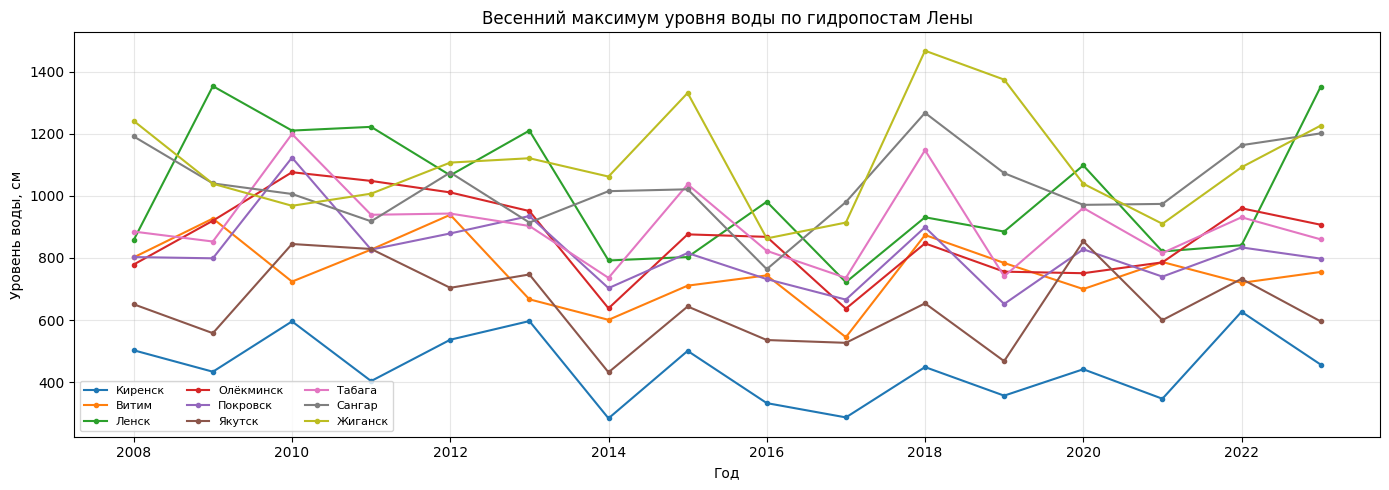

→ data/water_level_spring_peaks.png
['Киренск', 'Витим', 'Ленск', 'Олёкминск', 'Покровск', 'Якутск', 'Табага', 'Сангар', 'Жиганск']


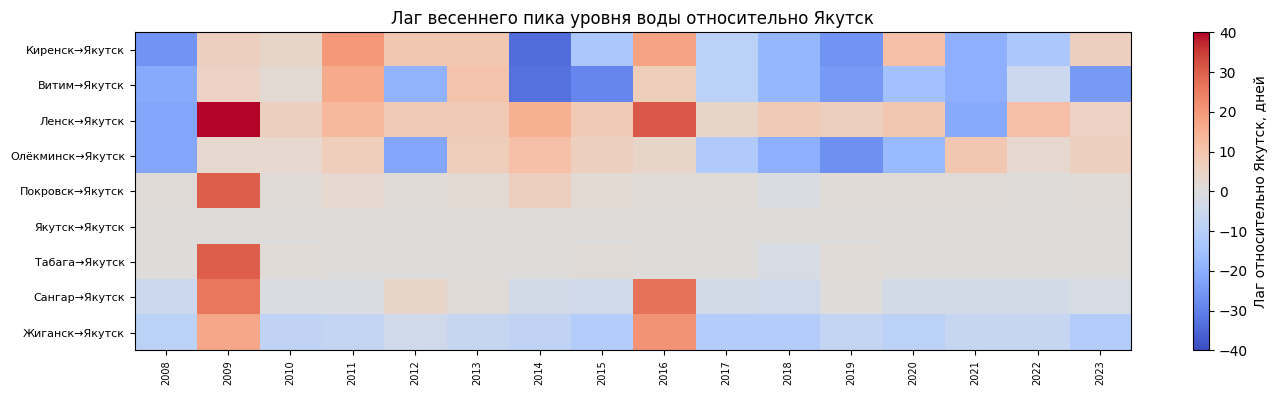

→ data/water_level_peak_lags_якутск.png


In [84]:
if water.empty:
    print('Нет данных уровня воды: загрузите CSV в data/hydro/ или data/water_level_lena.csv')
    df_water_features = pd.DataFrame()
    df_water_peak_lags = pd.DataFrame()
else:
    # Корреляция в порядке постов
    monthly = monthly.reindex(columns=[p for p in post_order if p in monthly.columns])
    corr = monthly.corr(min_periods=12)
    corr = corr.reindex(index=monthly.columns, columns=monthly.columns)

    print('\n=== Корреляция среднемесячных уровней между постами ===')
    print(corr.round(2).to_string())

    # Экспорт результатов анализа
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    df_water_features.to_csv(RESULTS_DIR / 'water_level_annual_features.csv', index=False, encoding='utf-8-sig')
    if not df_water_peak_lags.empty:
        df_water_peak_lags.to_csv(RESULTS_DIR / f'water_level_peak_lags_{REF_POST.lower()}.csv', encoding='utf-8-sig')
    corr.to_csv(RESULTS_DIR / 'water_level_monthly_corr.csv', encoding='utf-8-sig')

    print('\n→ результаты/water_level_annual_features.csv')
    if not df_water_peak_lags.empty:
        print(f'→ результаты/water_level_peak_lags_{REF_POST.lower()}.csv')
    print('→ результаты/water_level_monthly_corr.csv')

    # Визуализация 1: годовые весенние пики по ключевым постам
    key_posts = [p for p in ['Киренск', 'Витим', 'Ленск', 'Олёкминск', 'Покровск', 'Якутск', 'Табага', 'Сангар', 'Жиганск']
                 if p in set(df_water_features['post'])]
    if key_posts:
        key_posts = [p for p in post_order if p in key_posts]  # строго по заданному порядку
        fig, ax = plt.subplots(figsize=(14, 5))
        for post in key_posts:
            d = df_water_features[df_water_features['post'] == post].sort_values('year')
            ax.plot(d['year'], d['spring_peak_cm'], marker='o', lw=1.5, ms=3, label=post)
        ax.set_title('Весенний максимум уровня воды по гидропостам Лены')
        ax.set_xlabel('Год')
        ax.set_ylabel('Уровень воды, см')
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.savefig(DATA_DIR / 'water_level_spring_peaks.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('→ data/water_level_spring_peaks.png')

    # Визуализация 2: тепловая карта лагов пика относительно REF_POST
    if not df_water_peak_lags.empty:
        plot_lags = df_water_peak_lags.dropna(how='all')
        if not plot_lags.empty:
            row_series = []
            row_labels = []

            # Добавим референсную строку (нулевые лаги)
            #row_series.append(pd.Series(0.0, index=plot_lags.index, name=f'{REF_POST}→{REF_POST}'))
            #row_labels.append(f'{REF_POST}→{REF_POST}')

            # Посты в порядке убывания высоты / профиля
            print(post_order)
            for p in post_order:
                if p == REF_POST:
                    # Вставляем референсную строку в его место в post_order
                    row_series.append(pd.Series(0.0, index=plot_lags.index, name=f'{REF_POST}→{REF_POST}'))
                    row_labels.append(f'{REF_POST}→{REF_POST}')
                else:
                    c = f'лаг пика {p}→{REF_POST}, дней'
                    if c in plot_lags.columns:
                        row_series.append(plot_lags[c].rename(f'{p}→{REF_POST}'))
                        row_labels.append(f'{p}→{REF_POST}')

            # Добавим неизвестные колонки (если есть)
            used = {f'лаг пика {p}→{REF_POST}, дней' for p in post_order if p != REF_POST}
            for c in plot_lags.columns:
                if c not in used:
                    label = c.replace('лаг пика ', '').replace(', дней', '')
                    row_series.append(plot_lags[c].rename(label))
                    row_labels.append(label)

            ordered_plot_lags = pd.DataFrame(row_series, index=row_labels)

            fig, ax = plt.subplots(figsize=(14, max(3, 0.45 * len(ordered_plot_lags.index))))
            mat = ordered_plot_lags.values.astype(float)
            vmax = np.nanmax(np.abs(mat)) if np.any(~np.isnan(mat)) else 1.0
            im = ax.imshow(mat, aspect='auto', cmap='coolwarm', vmin=-vmax, vmax=vmax)

            ax.set_yticks(range(len(ordered_plot_lags.index)))
            ax.set_yticklabels(ordered_plot_lags.index, fontsize=8)
            ax.set_xticks(range(len(ordered_plot_lags.columns)))
            ax.set_xticklabels(ordered_plot_lags.columns.astype(str), rotation=90, fontsize=7)

            plt.colorbar(im, ax=ax, label=f'Лаг относительно {REF_POST}, дней')
            ax.set_title(f'Лаг весеннего пика уровня воды относительно {REF_POST}')
            plt.tight_layout()
            plt.savefig(DATA_DIR / f'water_level_peak_lags_{REF_POST.lower()}.png', dpi=150, bbox_inches='tight')
            plt.show()
            print(f'→ data/water_level_peak_lags_{REF_POST.lower()}.png')

## 5A. Лаги весенней оттепели и гидрологические триггеры ЧС

Блок решает две задачи:
1. Оценивает пространственно-временной сдвиг устойчивой весенней оттепели вдоль доступного профиля Лены.
2. Связывает весенние гидрологические пики в Якутске с фактическими гидрологическими ЧС в окне 0-30 дней.

Примечание: в текущем архиве TTTR нет станции Ленск (24671), поэтому верхний створ профиля выбирается автоматически из доступных станций Лены.

In [ ]:
# [Cell 1: Подготовка данных для лагов оттепели и увязки с ЧС]
THAW_MONTH_START = 3
THAW_MONTH_END = 5
THAW_ROLLING_DAYS = 7
THAW_STREAK_DAYS = 5
HYDRO_WINDOW_DAYS = 30
ANALYSIS_YEARS = list(range(2008, 2024))

HYDRO_CHS_PATTERNS = ('затор', 'павод', 'половод', 'подтоп')
THAW_REFERENCE_PRIORITY = [24671, 24944, 30230]
HYDRO_TRIGGER_Z_PRIMARY = 2.0
HYDRO_TRIGGER_Z_FALLBACK = 1.5

station_name_map = {}
if 'station_id' in df_air.columns:
    station_name_map = (
        df_air[['station_id', 'station_name']]
        .dropna(subset=['station_id'])
        .drop_duplicates(subset=['station_id'])
        .set_index('station_id')['station_name']
        .to_dict()
    )

available_profile = [station_id for station_id in LENA_PROFILE if station_id in set(df_air['station_id'].dropna().astype(int))]
yakutsk_station_id = next((station_id for station_id, name in station_name_map.items() if name == 'Якутск'), 24959)
upstream_station_id = next(
    (
        station_id
        for station_id in THAW_REFERENCE_PRIORITY + available_profile
        if station_id in available_profile and station_id != yakutsk_station_id
    ),
    None,
)

if upstream_station_id is None:
    raise ValueError('Для анализа лагов оттепели не найден верхний створ профиля Лены с данными температуры воздуха.')

ths_profile_names = [station_name_map.get(station_id, str(station_id)) for station_id in available_profile]
print('Профиль оттепели:', ' -> '.join(ths_profile_names))
print('Референсный верхний створ:', station_name_map.get(upstream_station_id, upstream_station_id))
print('Целевой створ:', station_name_map.get(yakutsk_station_id, yakutsk_station_id))

hydro_chs_file = DATA_DIR / 'mchs_events.csv'
df_chs = pd.read_csv(hydro_chs_file, parse_dates=['date_start', 'date_end'])
df_chs_hydro = df_chs[
    df_chs['type_chs']
    .fillna('')
    .str.lower()
    .str.contains('|'.join(HYDRO_CHS_PATTERNS), regex=True)
].copy()

print(f'Гидрологических ЧС в базе: {len(df_chs_hydro)}')
print(df_chs_hydro[['date_start', 'type_chs', 'location']].head())

In [ ]:
# [Cell 2: Вычисление температурного прокси вскрытия льда и лагов]
def get_thaw_date(station_daily: pd.DataFrame, year: int) -> pd.Timestamp | pd.NaT:
    """Возвращает первый день устойчивой весенней оттепели для выбранного года."""
    spring = station_daily[
        (station_daily['date'].dt.year == year)
        & (station_daily['date'].dt.month >= THAW_MONTH_START)
        & (station_daily['date'].dt.month <= THAW_MONTH_END)
    ].copy()
    if spring.empty:
        return pd.NaT

    spring = spring.sort_values('date')
    spring['tmean_7d_roll'] = spring['tmean'].rolling(window=THAW_ROLLING_DAYS, min_periods=THAW_ROLLING_DAYS).mean()
    spring['is_thaw'] = spring['tmean_7d_roll'] > 0
    streak_groups = spring['is_thaw'].ne(spring['is_thaw'].shift()).cumsum()
    spring['thaw_streak'] = spring['is_thaw'].groupby(streak_groups).cumsum()

    thaw_days = spring.loc[spring['thaw_streak'] >= THAW_STREAK_DAYS, 'date']
    if thaw_days.empty:
        return pd.NaT
    return thaw_days.iloc[0] - pd.Timedelta(days=THAW_STREAK_DAYS - 1)


thaw_records = []
for station_id in available_profile:
    station_daily = (
        df_air.loc[df_air['station_id'] == station_id, ['date', 'station_id', 'station_name', 'tmean']]
        .dropna(subset=['date', 'tmean'])
        .sort_values('date')
        .copy()
    )
    if station_daily.empty:
        continue

    for year in ANALYSIS_YEARS:
        thaw_date = get_thaw_date(station_daily, year)
        thaw_records.append({
            'year': year,
            'station_id': station_id,
            'station_name': station_name_map.get(station_id, str(station_id)),
            'thaw_date': thaw_date,
        })

df_thaw_dates = pd.DataFrame(thaw_records)
df_thaw_dates = df_thaw_dates.dropna(subset=['thaw_date']).sort_values(['year', 'station_id']).reset_index(drop=True)

thaw_pivot = df_thaw_dates.pivot(index='year', columns='station_id', values='thaw_date')
lag_rows = []
for year in ANALYSIS_YEARS:
    row = {'year': year}
    if year in thaw_pivot.index:
        for station_id in available_profile:
            if station_id == yakutsk_station_id:
                continue
            if station_id in thaw_pivot.columns and yakutsk_station_id in thaw_pivot.columns:
                row[f'lag_{station_id}_to_{yakutsk_station_id}_days'] = (
                    thaw_pivot.loc[year, yakutsk_station_id] - thaw_pivot.loc[year, station_id]
                ).days if pd.notna(thaw_pivot.loc[year, station_id]) and pd.notna(thaw_pivot.loc[year, yakutsk_station_id]) else np.nan

        if upstream_station_id in thaw_pivot.columns and yakutsk_station_id in thaw_pivot.columns:
            upstream_date = thaw_pivot.loc[year, upstream_station_id]
            yakutsk_date = thaw_pivot.loc[year, yakutsk_station_id]
            row['thaw_upstream_date'] = upstream_date
            row['thaw_yakutsk_date'] = yakutsk_date
            row['lag_upstream_to_yakutsk_days'] = (
                (yakutsk_date - upstream_date).days
                if pd.notna(upstream_date) and pd.notna(yakutsk_date)
                else np.nan
            )
    lag_rows.append(row)

df_lena_thaw_lags = pd.DataFrame(lag_rows)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
df_lena_thaw_lags.to_csv(RESULTS_DIR / 'lena_thaw_lags.csv', index=False, encoding='utf-8-sig')

summary_cols = ['year', 'thaw_upstream_date', 'thaw_yakutsk_date', 'lag_upstream_to_yakutsk_days']
print('Средний лаг устойчивой оттепели вверх по Лене -> Якутск:', round(df_lena_thaw_lags['lag_upstream_to_yakutsk_days'].dropna().mean(), 2), 'дней')
display(df_lena_thaw_lags[summary_cols].dropna(subset=['lag_upstream_to_yakutsk_days']).head(10))

In [ ]:
# [Cell 3: Расчет весенних максимумов и гидрологических триггеров]
if df_water_features.empty:
    raise ValueError('Гидрологические признаки не рассчитаны: сначала выполните блок анализа уровня воды.')

df_yakutsk_hydro = (
    df_water_features[df_water_features['post'] == 'Якутск']
    .copy()
    .sort_values('year')
    .reset_index(drop=True)
)

if df_yakutsk_hydro.empty:
    raise ValueError('В df_water_features нет данных по посту Якутск.')

df_yakutsk_hydro['hydro_trigger_z'] = df_yakutsk_hydro[['spring_peak_cm_z', 'max_rise_7d_cm_day_z']].max(axis=1, skipna=True)
df_yakutsk_hydro['trigger_metric'] = np.where(
    df_yakutsk_hydro['spring_peak_cm_z'].fillna(-np.inf) >= df_yakutsk_hydro['max_rise_7d_cm_day_z'].fillna(-np.inf),
    'spring_peak_cm_z',
    'max_rise_7d_cm_day_z',
)

applied_trigger_threshold = HYDRO_TRIGGER_Z_PRIMARY
trigger_mask = (
    df_yakutsk_hydro['spring_peak_cm_z'].ge(HYDRO_TRIGGER_Z_PRIMARY)
    | df_yakutsk_hydro['max_rise_7d_cm_day_z'].ge(HYDRO_TRIGGER_Z_PRIMARY)
)
if not trigger_mask.any():
    applied_trigger_threshold = HYDRO_TRIGGER_Z_FALLBACK
    trigger_mask = (
        df_yakutsk_hydro['spring_peak_cm_z'].ge(HYDRO_TRIGGER_Z_FALLBACK)
        | df_yakutsk_hydro['max_rise_7d_cm_day_z'].ge(HYDRO_TRIGGER_Z_FALLBACK)
    )
    print(f'Строгий порог z >= {HYDRO_TRIGGER_Z_PRIMARY} не дал триггеров; применен fallback z >= {HYDRO_TRIGGER_Z_FALLBACK}.')

df_hydro_anomalies = df_yakutsk_hydro.loc[trigger_mask].copy()
df_hydro_anomalies['applied_trigger_threshold'] = applied_trigger_threshold
df_hydro_anomalies['severity'] = np.where(df_hydro_anomalies['hydro_trigger_z'] >= 3, 'extreme', 'moderate')
df_hydro_anomalies['risk_points'] = np.where(df_hydro_anomalies['severity'] == 'extreme', 3, 2)

df_hydro_anomalies = df_hydro_anomalies[
    [
        'year',
        'spring_peak_date',
        'spring_peak_cm',
        'spring_peak_cm_z',
        'max_rise_7d_cm_day',
        'max_rise_7d_cm_day_z',
        'hydro_trigger_z',
        'trigger_metric',
        'applied_trigger_threshold',
        'severity',
        'risk_points',
    ]
].rename(columns={'spring_peak_date': 'anomaly_date'})

df_hydro_anomalies.to_csv(RESULTS_DIR / 'yakutsk_hydro_anomalies.csv', index=False, encoding='utf-8-sig')

print('Гидрологические триггеры (Якутск):')
display(df_hydro_anomalies)

In [ ]:
# [Cell 4: Увязка гидрологических триггеров с базой ЧС]
linked_events = []

for _, anomaly in df_hydro_anomalies.iterrows():
    if pd.isna(anomaly['anomaly_date']):
        continue

    window_start = anomaly['anomaly_date']
    window_end = window_start + pd.Timedelta(days=HYDRO_WINDOW_DAYS)
    matched_chs = df_chs_hydro[
        (df_chs_hydro['date_start'] >= window_start)
        & (df_chs_hydro['date_start'] <= window_end)
    ].copy()

    thaw_info = df_lena_thaw_lags[df_lena_thaw_lags['year'] == anomaly['year']]
    thaw_info = thaw_info.iloc[0] if not thaw_info.empty else pd.Series(dtype=object)

    for _, chs in matched_chs.iterrows():
        lag_days = int((chs['date_start'] - anomaly['anomaly_date']).days)
        if lag_days <= 3:
            lag_bin = '0-3 days'
        elif lag_days <= 7:
            lag_bin = '4-7 days'
        elif lag_days <= 14:
            lag_bin = '8-14 days'
        else:
            lag_bin = '15-30 days'

        linked_events.append({
            'year': anomaly['year'],
            'anomaly_date': anomaly['anomaly_date'],
            'spring_peak_cm': anomaly['spring_peak_cm'],
            'spring_peak_z': anomaly['spring_peak_cm_z'],
            'max_rise_7d_cm_day': anomaly['max_rise_7d_cm_day'],
            'max_rise_7d_z': anomaly['max_rise_7d_cm_day_z'],
            'hydro_trigger_z': anomaly['hydro_trigger_z'],
            'trigger_metric': anomaly['trigger_metric'],
            'severity': anomaly['severity'],
            'risk_points': anomaly['risk_points'],
            'thaw_upstream_date': thaw_info.get('thaw_upstream_date', pd.NaT),
            'thaw_yakutsk_date': thaw_info.get('thaw_yakutsk_date', pd.NaT),
            'thaw_lag_upstream_to_yakutsk_days': thaw_info.get('lag_upstream_to_yakutsk_days', np.nan),
            'chs_date': chs['date_start'],
            'chs_type': chs['type_chs'],
            'chs_location': chs.get('location', np.nan),
            'lag_days': lag_days,
            'lag_bin': lag_bin,
        })

df_linked = pd.DataFrame(linked_events)
df_linked.to_csv(RESULTS_DIR / 'yakutsk_hydro_chs_links.csv', index=False, encoding='utf-8-sig')

if df_linked.empty:
    print('В окне 0-30 дней после гидрологических триггеров ЧС не найдены.')
else:
    display(df_linked.sort_values(['anomaly_date', 'chs_date']))
    print('\nРаспределение ЧС по временным окнам после гидрологического триггера:')
    print(df_linked['lag_bin'].value_counts().sort_index())

    print('\nКоличество связанных ЧС по годам:')
    print(df_linked.groupby('year').size())

## 6. СТС / ALT (CALM network)

Источник: https://www2.gwu.edu/~calm/data/data-links.htm  
Формат: Excel-таблица, годовые данные по площадкам

In [85]:
calm_file = DATA_DIR / 'СТС.csv'

if calm_file.exists():
    print(f'Файл: {calm_file}')
    try:
        df_calm_raw = pd.read_csv(calm_file, encoding='utf-8-sig')
        if df_calm_raw.shape[1] == 1:
            df_calm_raw = pd.read_csv(calm_file, sep=';', encoding='utf-8-sig')
    except UnicodeDecodeError:
        df_calm_raw = pd.read_csv(calm_file, sep=';', encoding='cp1251')

    # Координаты наших станций (центр области поиска)
    STATION_COORDS = {
        'Верхоянск': (67.55, 133.39),
        'Жиганск':   (66.77, 123.37),
        'Якутск':    (62.02, 129.72),
        'Оймякон':   (63.46, 142.77),
    }

    # Показываем все доступные регионы
    print('Регионы в CALM:', df_calm_raw['Region'].unique().tolist())

    # Фильтр: Якутия — North East Siberia + координатный bbox
    # (примерно: 60–72°N, 118–150°E)
    mask = (
        df_calm_raw['LAT'].between(60, 72) &
        df_calm_raw['LONG'].between(118, 150)
    )
    df_yakutia = df_calm_raw[mask].copy()
    print(f'\nПлощадки в Якутии (bbox): {len(df_yakutia)}')
    print(df_yakutia[['Site Code', 'Site Name', 'LAT', 'LONG']].to_string(index=False))

    # Перевод wide → long
    year_cols = [c for c in df_calm_raw.columns if c.isdigit()]
    df_calm = df_yakutia.melt(
        id_vars=['Site Code', 'Site Name', 'LAT', 'LONG', 'Method'],
        value_vars=year_cols,
        var_name='year',
        value_name='alt_cm'
    )
    df_calm['year'] = df_calm['year'].astype(int)
    # Убираем нечисловые значения ('inactive', пустые строки)
    df_calm['alt_cm'] = pd.to_numeric(df_calm['alt_cm'], errors='coerce')
    df_calm = df_calm.dropna(subset=['alt_cm'])

    print(f'\nИтого наблюдений: {len(df_calm)}')
    print(f'Период: {df_calm["year"].min()} — {df_calm["year"].max()}')
    print(df_calm.head(10))
else:
    print('Файл data/СТС.csv не найден')
    df_calm = pd.DataFrame()

Файл: data/СТС.csv
Регионы в CALM: ['West Siberia', 'Russian Far East', 'North East Siberia', 'Russian European North', 'Central Siberia', 'Kamchatka']

Площадки в Якутии (bbox): 11
Site Code                         Site Name       LAT       LONG
     R29A     Bykovsky (Lena delta) (edoma) 71.785500 129.418700
     R29B      Bykovsky (Lena delta) (alas) 71.784300 129.401400
     R29C Bykovsky (Lena delta) (edoma new) 71.786944 129.420833
      R31         Allaiha (Indigirka basin) 70.564500 147.431500
     R31A   Allaiha (Indigirka basin, alas) 70.566700 147.416700
      R42          Tuymada (Yakutsk region) 62.013300 129.657000
      R43          Neleger (Yakutsk region) 62.316300 129.499700
      R51                          Samoylov 72.000000 126.000000
       R8         Tiksi (Game), Lena Delta  71.583000 128.783000
      NaN                  Anmangynda River 60.913697 149.810072
      NaN                        Ust'Omchyg 61.096637 149.629691

Итого наблюдений: 121
Период: 1997 — 

In [86]:
# Фильтр периода анализа: 2008–2023
START_YEAR, END_YEAR = 2008, 2023

if not df_calm.empty and 'year' in df_calm.columns:
    before = len(df_calm)
    df_calm['year'] = pd.to_numeric(df_calm['year'], errors='coerce')
    df_calm = df_calm[df_calm['year'].between(START_YEAR, END_YEAR)].copy()
    df_calm['year'] = df_calm['year'].astype(int)
    print(f'СТС / ALT: оставлено {len(df_calm)} из {before} строк за {START_YEAR}–{END_YEAR} гг.')
    if not df_calm.empty:
        print(f'Период после фильтра: {df_calm["year"].min()} — {df_calm["year"].max()}')


СТС / ALT: оставлено 92 из 121 строк за 2008–2023 гг.
Период после фильтра: 2008 — 2023


In [87]:
# ── Ряды глубины СТС (ALT) для всех 11 найденных площадок Якутии ──────────
# Для детекции аномальных лет используем только площадки R42 и R43.
ALT_SITE_CODES = ['R42', 'R43']

if not df_calm.empty:
    yakutia_sites = (
        df_yakutia[['Site Code', 'Site Name']]
        .assign(site_id=lambda x: x['Site Code'].fillna(x['Site Name']))
        .drop_duplicates(subset=['site_id', 'Site Name'])
        .set_index(['site_id', 'Site Name'])
    )
    df_alt_yak = (
        df_calm[['Site Code', 'Site Name', 'year', 'alt_cm']]
        .assign(site_id=lambda x: x['Site Code'].fillna(x['Site Name']))
        .sort_values(['site_id', 'year'])
        .reset_index(drop=True)
    )
    df_alt_yak_wide = (
        df_alt_yak.pivot_table(
            index=['site_id', 'Site Name'],
            columns='year',
            values='alt_cm',
            aggfunc='first'
        )
        .reindex(yakutia_sites.index)
    )
    print(f'Глубина СТС (ALT) — все площадки Якутии: {len(df_alt_yak_wide)} рядов')
    print(df_alt_yak_wide.to_string())

    df_alt_sites = df_alt_yak[df_alt_yak['site_id'].isin(ALT_SITE_CODES)].copy()
    alt_series_by_site = {
        site_id: (
            grp.groupby('year')['alt_cm']
            .mean()
            .sort_index()
            .rename(f'ALT_{site_id}')
        )
        for site_id, grp in df_alt_sites.groupby('site_id')
    }

    # Средний ряд по R42/R43 оставлен для совместимости с другими ячейками.
    if alt_series_by_site:
        alt_series = pd.concat(alt_series_by_site, axis=1).mean(axis=1).sort_index()
        alt_series.name = 'ALT_R42_R43_mean'
        print('ALT для анализа аномалий:')
        for site_id in ALT_SITE_CODES:
            s = alt_series_by_site.get(site_id, pd.Series(dtype=float))
            if s.empty:
                print(f'  {site_id}: нет наблюдений')
            else:
                print(f'  {site_id}: {s.notna().sum()} лет ({int(s.index.min())}–{int(s.index.max())})')
    else:
        alt_series = pd.Series(dtype=float, name='ALT_R42_R43_mean')
        print('ALT для анализа аномалий: по точкам R42/R43 нет наблюдений')
else:
    print('Нет данных CALM — ALT не вычислен')
    df_alt_yak = pd.DataFrame()
    df_alt_yak_wide = pd.DataFrame()
    df_alt_sites = pd.DataFrame()
    alt_series_by_site = {}
    alt_series = pd.Series(dtype=float, name='ALT_R42_R43_mean')


Глубина СТС (ALT) — все площадки Якутии: 11 рядов
year                                                 2008   2009   2010   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023
site_id          Site Name                                                                                                                                        
R29A             Bykovsky (Lena delta) (edoma)       38.0   28.0   38.0   39.0   33.0   26.0   35.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN
R29B             Bykovsky (Lena delta) (alas)        37.0   25.0   28.0   35.0   30.0   24.0   33.0   30.0   30.0   26.0   36.0    NaN   41.0   31.0   35.0   32.0
R29C             Bykovsky (Lena delta) (edoma new)    NaN    NaN    NaN    NaN    NaN    NaN    NaN   34.0   29.0   30.0   38.0    NaN   42.0   36.0   38.0   34.0
R31              Allaiha (Indigirka basin)           47.0   49.0   52.0   52.0   50.0   47.0   47.0   46.0   49.0   41.0   39.0    NaN 

## 7. Расчёт TDD и FDD

Используем температуру **воздуха** (TTTR) как основу для TDD/FDD.  
Дополнительно используем температуру **почвы** на глубинах 20–80 см для верификации.

In [88]:
def compute_degree_days(
    df_air: pd.DataFrame, df_snow_all: pd.DataFrame, df_soil_all: pd.DataFrame, station_id: int
) -> pd.DataFrame:
    """TDD / FDD / зимние_оттепели / макс_суточные_осадки (из df_air)

    + макс_высота_снега (из df_snow) + весенние осадки (из df_air) для одной
    станции. Учитывает сквозные зимние сезоны (ноябрь N-1 -> март/апрель N).
    """
    # ─── 1. Обработка данных воздуха (df_air) ────────────────────────────────
    df = df_air[df_air["station_id"] == station_id].copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    # Летний период для TDD (апрель - октябрь) — тут всё в рамках одного года
    summer = df[df["month"].between(4, 10)]
    tdd = (
        summer.assign(v=summer["tmean"].clip(lower=0))
        .groupby("year")["v"]
        .sum()
        .rename("TDD")
    )

    # Для зимних индексов (FDD и оттепели) вводим понятие зимнего сезона:
    # Ноябрь и Декабрь текущего года относятся к зимнему сезону СЛЕДУЮЩЕГО года.
    df["winter_season"] = df.apply(
        lambda row: (
            row["year"] + 1 if row["month"] in (11, 12) else row["year"]
        ),
        axis=1,
    )

    winter = df[~df["month"].between(4, 10)]
    fdd = (
        winter.assign(v=(-winter["tmean"]).clip(lower=0))
        .groupby("winter_season")["v"]
        .sum()
        .rename("FDD")
    )
    thaw = (
        winter.assign(v=(winter["tmean"] > 0))
        .groupby("winter_season")["v"]
        .sum()
        .rename("winter_thaw_days")
    )

    # Максимальные суточные осадки за календарный год
    max_p = df.groupby("year")["precip_mm"].max().rename("max_daily_precip")

    # Весенние осадки (апрель - май) текущего года
    spring = df[df["month"].between(4, 5)]
    spring_precip = (
        spring.groupby("year")["precip_mm"].sum().rename("spring_precip")
    )

    # ─── 2. РАСЧЕТ СНЕГА (С учетом сквозного сезона) ─────────────────────────
    station_snow = df_snow_all[
        df_snow_all["station_id"] == station_id
    ].copy()

    if not station_snow.empty:
        station_snow["year"] = station_snow["date"].dt.year
        station_snow["month"] = station_snow["date"].dt.month

        # Создаем сквозной зимний сезон для снега: ноябрь и декабрь сдвигаем на +1 год вверх.
        # Теперь ноябрь-декабрь 2017 и январь-апрель 2018 соберутся под меткой 2018 года.
        station_snow["snow_season"] = station_snow.apply(
            lambda row: (
                row["year"] + 1 if row["month"] in (11, 12) else row["year"]
            ),
            axis=1,
        )

        # Выделяем период накопления сугробов (ноябрь, декабрь, январь, февраль, март, апрель)
        snow_months = [11, 12, 1, 2, 3, 4]
        snow_accumulation = station_snow[
            station_snow["month"].isin(snow_months)
        ]

        # Группируем именно по snow_season, вычисляя пиковую высоту сугробов, которая растает весной этого сезона
        max_snow = (
            snow_accumulation.groupby("snow_season")["snow_depth_cm"]
            .max()
            .rename("max_snow_depth")
        )
    else:
        max_snow = pd.Series(dtype=float, name="max_snow_depth")


    # ─── 3. РАСЧЕТ ПАРАМЕТРОВ МЕРЗЛОТЫ (MAGST, TTOP, SO, TO, N-factors) ──────
    if not df_soil_all.empty:
        station_soil = df_soil_all[df_soil_all["station_id"] == station_id].copy()
    else:
        station_soil = pd.DataFrame()

    if not station_soil.empty:
        station_soil["year"] = station_soil["date"].dt.year
        station_soil["month"] = station_soil["date"].dt.month
        
        # MAGST (Mean Annual Ground Surface Temperature) - берем t2cm или t5cm
        if 't20cm' in station_soil.columns:
            magst = station_soil.groupby("year")["t20cm"].mean().rename("MAGST")
        else:
            magst = pd.Series(dtype=float, name="MAGST")
            
        # TTOP (Temperature at the Top of Permafrost) - берем t160cm или t320cm
        if 't160cm' in station_soil.columns:
            ttop = station_soil.groupby("year")["t160cm"].mean().rename("TTOP")
        elif 't320cm' in station_soil.columns:
            ttop = station_soil.groupby("year")["t320cm"].mean().rename("TTOP")
        else:
            ttop = pd.Series(dtype=float, name="TTOP")
            
        # MAAT (Mean Annual Air Temperature)
        maat = df.groupby("year")["tmean"].mean().rename("MAAT")
        
        # Surface Offset (SO) = MAGST - MAAT
        so = (magst - maat).rename("SO")
        
        # Thermal Offset (TO) = TTOP - MAGST
        to = (ttop - magst).rename("TO")
        
        # N-factors
        summer_soil = station_soil[station_soil["month"].between(4, 10)]
        if 't20cm' in summer_soil.columns:
            tdd_soil = summer_soil.assign(v=summer_soil["t20cm"].clip(lower=0)).groupby("year")["v"].sum()
            n_t = (tdd_soil / tdd).rename("N_t")
        else:
            n_t = pd.Series(dtype=float, name="N_t")
            
        station_soil["winter_season"] = station_soil.apply(
            lambda row: row["year"] + 1 if row["month"] in (11, 12) else row["year"], axis=1
        )
        winter_soil = station_soil[~station_soil["month"].between(4, 10)]
        if 't20cm' in winter_soil.columns:
            fdd_soil = winter_soil.assign(v=(-winter_soil["t20cm"]).clip(lower=0)).groupby("winter_season")["v"].sum()
            n_f = (fdd_soil / fdd).rename("N_f")
        else:
            n_f = pd.Series(dtype=float, name="N_f")
            
    else:
        magst = pd.Series(dtype=float, name="MAGST")
        ttop = pd.Series(dtype=float, name="TTOP")
        so = pd.Series(dtype=float, name="SO")
        to = pd.Series(dtype=float, name="TO")
        n_t = pd.Series(dtype=float, name="N_t")
        n_f = pd.Series(dtype=float, name="N_f")

    # Склеиваем все параметры по индексу года (для FDD и снега индексом стал честный сезон)
    df_res = pd.concat(
        [tdd, fdd, thaw, max_p, spring_precip, max_snow, magst, ttop, so, to, n_t, n_f], axis=1
    ).reset_index()

    # Переименовываем обратно в 'year' для совместимости со старым кодом объединения
    return df_res.rename(columns={"index": "year"})


# ─── Вычисление показателей по всем станциям профиля Лены ─────────────────
df_dd_all = {}
if not df_air.empty:
    avail_air = set(df_air["station_id"].unique())
    for sid in LENA_PROFILE:
        name = YAKUTIA_STATIONS[sid]
        if sid in avail_air:
            # 1. Считаем показатели (функция видит данные 2007 года и собирает ЧЕСТНЫЙ сезон 2008)
            res_df = compute_degree_days(df_air, df_snow, df_soil, sid)

            # 2. ИСПРАВЛЕНИЕ: Фильтруем строго в границах вашего исследования для ВКР (2008–2023)
            # Теперь 2008 год ПОЛНЫЙ и корректный, а неполный 2024 — отсекается.
            res_df = res_df[res_df["year"].between(2008, 2023)].copy()

            df_dd_all[name] = res_df
            yr = df_dd_all[name]
            print(
                f"  {name}: {len(yr)} лет, {yr['year'].min()}–{yr['year'].max()}"
            )
        else:
            print(
                f"  {name} (WMO {sid}): нет данных — загрузите файл в data/air/"
            )

    # Обновляем базовый датафрейм для Якутска
    df_dd = df_dd_all.get("Якутск", pd.DataFrame())
else:
    print("Нет данных температуры воздуха для расчёта TDD/FDD")
    df_dd, df_dd_all = pd.DataFrame(), {}

  Киренск: 16 лет, 2008–2023
  Олёкминск: 16 лет, 2008–2023
  Якутск: 16 лет, 2008–2023
  Жиганск: 16 лет, 2008–2023


## 8. Rain-on-Snow: детекция комбинированного триггера

Событие rain-on-snow = осадки зимой при Tmin > 0 (оттепель) + наличие снежного покрова.  
Критически важный триггер для заторов и наводнений.

Для годового анализа используется **физический сезон паводкового года**: события октября–декабря относятся к следующему году, потому что их эффект проявляется весной следующего календарного года. Январь–апрель относятся к текущему году.

In [112]:
ROS_START_YEAR, ROS_END_YEAR = 2008, 2023


def detect_rain_on_snow(df_air: pd.DataFrame, df_snow: pd.DataFrame,
                        station_id: int) -> pd.DataFrame:
    """Детектирует события rain-on-snow для конкретной станции.

    Сезонный год (`season_year`) соответствует весне, которая следует после
    осенне-зимнего периода: октябрь-декабрь N -> сезон N+1,
    январь-апрель N -> сезон N.
    """
    air  = df_air [df_air ['station_id'] == station_id][['date', 'tmin', 'tmean', 'precip_mm']].copy()
    snow = df_snow[df_snow['station_id'] == station_id][['date', 'snow_depth_cm']].copy()
    df   = air.merge(snow, on='date', how='inner')
    df['month'] = df['date'].dt.month
    df['season_year'] = np.where(
        df['month'].isin([10, 11, 12]),
        df['date'].dt.year + 1,
        df['date'].dt.year,
    ).astype(int)

    ros = df[
        (df['month'].isin([10, 11, 12, 1, 2, 3, 4])) &
        (df['tmean'] > 0) &
        (df['precip_mm'] > 1) &
        (df['snow_depth_cm'] > 5)
    ].copy()
    ros['station_id'] = station_id
    return ros


if not df_air.empty and not df_snow.empty:
    avail_air  = set(df_air ['station_id'].unique())
    avail_snow = set(df_snow['station_id'].unique())

    ros_all = []
    for sid in LENA_PROFILE:
        name = YAKUTIA_STATIONS[sid]
        if sid in avail_air and sid in avail_snow:
            ros = detect_rain_on_snow(df_air, df_snow, sid)
            ros['station_name'] = name
            ros_all.append(ros)
            print(f'  {name}: {len(ros)} событий rain-on-snow')
        else:
            print(f'  {name}: нет данных (воздух или снег не загружены)')

    ros_events = pd.concat(ros_all, ignore_index=True) if ros_all else pd.DataFrame()
    if not ros_events.empty:
        ros_events = ros_events[
            ros_events['season_year'].between(ROS_START_YEAR, ROS_END_YEAR)
        ].copy()
        print(f'\nВсего ROS событий за физические сезоны {ROS_START_YEAR}–{ROS_END_YEAR}: {len(ros_events)}')
        print(ros_events[['station_name', 'date', 'season_year', 'tmean', 'precip_mm', 'snow_depth_cm']].head(6))

        ros_annual = (
            ros_events
            .groupby(['station_name', 'season_year'], as_index=False)
            .agg(
                ros_event_days=('date', 'count'),
                ros_precip_sum=('precip_mm', 'sum'),
                ros_precip_max=('precip_mm', 'max'),
            )
            .rename(columns={'season_year': 'year'})
        )

        if 'df_dd_all' in globals() and df_dd_all:
            for station_name, station_df in list(df_dd_all.items()):
                station_ros = (
                    ros_annual[ros_annual['station_name'].eq(station_name)]
                    .drop(columns=['station_name'])
                )
                updated = station_df.merge(station_ros, on='year', how='left')
                for col in ['ros_event_days', 'ros_precip_sum', 'ros_precip_max']:
                    if col in updated.columns:
                        updated[col] = updated[col].fillna(0)
                df_dd_all[station_name] = updated
            df_dd = df_dd_all.get('Якутск', df_dd)
            print('ROS добавлен в годовые показатели df_dd_all как физический сезон паводкового года')
else:
    print('Нет данных для детекции rain-on-snow')
    ros_events = pd.DataFrame()


  Киренск: 31 событий rain-on-snow
  Олёкминск: 15 событий rain-on-snow
  Якутск: 8 событий rain-on-snow
  Жиганск: 22 событий rain-on-snow

Всего ROS событий за физические сезоны 2008–2023: 73
  station_name       date  season_year  tmean  precip_mm  snow_depth_cm
0      Киренск 2007-11-01         2008    0.2        2.1            7.0
1      Киренск 2008-04-16         2008    1.2        1.2            9.0
2      Киренск 2009-04-04         2009    5.2        1.2           40.0
3      Киренск 2010-10-29         2011    0.6        2.9           13.0
4      Киренск 2012-04-11         2012    4.1        1.7           28.0
5      Киренск 2012-04-12         2012    2.4        2.2           26.0
ROS добавлен в годовые показатели df_dd_all как физический сезон паводкового года


## 9. Детекция аномальных лет

Три метода:
- **Z-score** — отклонение от многолетней нормы за весь доступный период
- **Percentile** — P90/P95/P99 для верхних аномалий и P10/P5/P1 для нижних
- **Скользящее отклонение** — от 7-летней локальной нормы, рассчитанной по предыдущим годам

Для короткого ряда 2008–2023 гг. 10-летнее окно слишком длинное: оно даёт мало полноценных окон и нестабильную оценку разброса. Поэтому используется 7-летнее окно (`rolling_window=7`) с минимумом 4 предыдущих лет (`rolling_min_periods=4`). Текущий год не включается в локальную норму, чтобы аномальное значение не «подтягивало» базовую линию к себе.


In [ ]:
ANOMALY_ROLLING_WINDOW = 7
ANOMALY_ROLLING_MIN_PERIODS = 4


def detect_anomalies(
    series: pd.Series,
    name: str,
    high_is_bad: bool = True,
    rolling_window: int = ANOMALY_ROLLING_WINDOW,
    rolling_min_periods: int = ANOMALY_ROLLING_MIN_PERIODS,
) -> pd.DataFrame:
    """Математически корректный расчет аномальности климатического ряда для ВКР."""
    # Шаг 1. Приводим всё к единому вектору "чем больше значение, тем хуже"
    # Для FDD (high_is_bad=False) инвертируем значения (меньше градусов-дней -> больше тепла -> хуже)
    v = series if high_is_bad else -series

    # Шаг 2. Глобальные параметры Z-score (работаем с трансформированным вектором v)
    mean, std = v.mean(), v.std()
    z_bad = (
        (v - mean) / std
        if pd.notna(std) and std != 0
        else pd.Series(np.nan, index=series.index)
    )

    # Шаг 3. Квантили (теперь всегда ищем правый хвост распределения, т.к. вектор инвертирован)
    p_moderate = v.quantile(0.95)
    p_extreme = v.quantile(0.99)

    # Шаг 4. Локальное скользящее окно (строго по прошлым годам)
    # Используем shift(1), чтобы текущий год не влиял на историческое среднее его пятилетки/семилетки
    v_prev = v.shift(1)
    rolling_mean = v_prev.rolling(
        rolling_window, min_periods=rolling_min_periods
    ).mean()
    rolling_std = v_prev.rolling(
        rolling_window, min_periods=rolling_min_periods
    ).std()

    # Локальный Z-score
    rolling_z_bad = (
        (v - rolling_mean) / rolling_std
        if rolling_std.notna().any()
        else pd.Series(np.nan, index=series.index)
    )

    # Шаг 5. Формирование флагов (критерии стали линейными и прозрачными)
    percentile_moderate = v >= p_moderate
    percentile_extreme = v >= p_extreme

    z_moderate = z_bad >= 2.0
    z_extreme = z_bad >= 3.0

    rolling_moderate = rolling_z_bad >= 2.0
    rolling_extreme = rolling_z_bad >= 3.0

    # Собираем итоговый DataFrame
    return pd.DataFrame({
        name: series,  # Возвращаем исходные физические значения для таблицы
        f"{name}_z": z_bad.round(2),
        f"{name}_rolling_mean_7y_prev": rolling_mean.round(2)
        if high_is_bad
        else -rolling_mean.round(2),
        f"{name}_rolling_z_7y_prev": rolling_z_bad.round(2),
        f"{name}_anomaly_moderate": z_moderate
        | percentile_moderate
        | rolling_moderate,
        f"{name}_anomaly_extreme": z_extreme
        | percentile_extreme
        | rolling_extreme,
    })


# Словарь, где будут храниться итоговые таблицы аномалий для каждой метеостанции
df_anom_all = {}

if df_dd_all:
    print(
        f"=== СТАРТ АНАЛИЗА АНОМАЛИЙ ДЛЯ ВСЕХ СТАНЦИЙ ({len(df_dd_all)} шт.) ==="
    )

    for station_name, df_station in df_dd_all.items():
        if df_station.empty:
            print(f"\nСтанция {station_name}: нет данных для анализа")
            continue

        print(
            f"\n" + "=" * 60 + f"\n[АНАЛИЗ СТАНЦИИ]: {station_name.upper()}"
        )

        idx = df_station.set_index("year")

        # Базовые термические и осадочные параметры метеостанции
        anom_tdd = detect_anomalies(idx["TDD"], "TDD", high_is_bad=True)
        anom_fdd = detect_anomalies(idx["FDD"], "FDD", high_is_bad=False)
        anom_thaw = detect_anomalies(
            idx["winter_thaw_days"], "thaw_d", high_is_bad=True
        )
        anom_precip = detect_anomalies(
            idx["max_daily_precip"], "precip", high_is_bad=True
        )
        anom_precip_s = detect_anomalies(
            idx["spring_precip"], "precip_spring", high_is_bad=True
        )
        anom_snow = detect_anomalies(
            idx["max_snow_depth"], "max_snow_depth", high_is_bad=True
        )
        anom_ros = detect_anomalies(
            idx["ros_event_days"], "ros_event_days", high_is_bad=True
        ) if "ros_event_days" in idx.columns else pd.DataFrame(index=idx.index)
        anom_magst = detect_anomalies(idx["MAGST"], "MAGST", high_is_bad=True)
        anom_ttop = detect_anomalies(idx["TTOP"], "TTOP", high_is_bad=True)
        anom_so = detect_anomalies(idx["SO"], "SO", high_is_bad=True)
        anom_to = detect_anomalies(idx["TO"], "TO", high_is_bad=True)
        anom_nt = detect_anomalies(idx["N_t"], "N_t", high_is_bad=True)
        anom_nf = detect_anomalies(idx["N_f"], "N_f", high_is_bad=True)


        frames = [
            anom_tdd,
            anom_fdd,
            anom_thaw,
            anom_precip,
            anom_precip_s,
            anom_snow,
            anom_ros,
            anom_magst,
            anom_ttop,
            anom_so,
            anom_to,
            anom_nt,
            anom_nf,
        ]

        # ── ALT / СТС (CALM): Добавляем только к Якутску (где есть площадки мониторинга)
        alt_added = []
        if station_name == "Якутск":
            alt_sources = globals().get("alt_series_by_site", {})
            alt_site_codes = globals().get("ALT_SITE_CODES", ["R42", "R43"])

            for site_id in alt_site_codes:
                s = alt_sources.get(site_id, pd.Series(dtype=float))
                if s.empty:
                    print(
                        f"  ALT {site_id}: данных CALM нет, индикатор пропущен"
                    )
                    continue

                col_name = f"ALT_{site_id}"
                anom_alt = detect_anomalies(
                    s.reindex(idx.index), col_name, high_is_bad=True
                )
                frames.append(anom_alt)
                alt_added.append(col_name)
                print(
                    f"  ALT {site_id} включён в анализ: {s.notna().sum()} лет наблюдений"
                )

        # Конкатенируем все профили аномалий текущей станции
        df_anom = pd.concat(frames, axis=1)

        # Считаем количество одновременно сработавших флагов аномалий
        mod_cols = [c for c in df_anom.columns if "anomaly_moderate" in c]
        ext_cols = [c for c in df_anom.columns if "anomaly_extreme" in c]
        df_anom["n_moderate"] = df_anom[mod_cols].sum(axis=1).astype(int)
        df_anom["n_extreme"] = df_anom[ext_cols].sum(axis=1).astype(int)

        # Функция формирования текстового лога (замыкание использует контекст текущей станции)
        def describe_anomaly_indicators(row: pd.Series, level: str) -> str:
            suffix = f"_anomaly_{level}"
            cols = mod_cols if level == "moderate" else ext_cols
            parts = []

            for flag_col in cols:
                if not bool(row.get(flag_col, False)):
                    continue

                indicator = flag_col.removesuffix(suffix)
                details = []

                value = row.get(indicator, np.nan)
                z_val = row.get(f"{indicator}_z", np.nan)
                rolling_z_val = row.get(
                    f"{indicator}_rolling_z_7y_prev", np.nan
                )

                if pd.notna(value):
                    details.append(f"значение={value:.1f}")
                if pd.notna(z_val):
                    details.append(f"z={z_val:.2f}")
                if pd.notna(rolling_z_val):
                    details.append(f"лок.z={rolling_z_val:.2f}")

                parts.append(
                    f'{indicator} ({", ".join(details)})'
                    if details
                    else indicator
                )

            return "; ".join(parts)

        df_anom["moderate_indicators"] = df_anom.apply(
            lambda row: describe_anomaly_indicators(row, "moderate"), axis=1
        )
        df_anom["extreme_indicators"] = df_anom.apply(
            lambda row: describe_anomaly_indicators(row, "extreme"), axis=1
        )

        # Списки аномальных лет для консольного отчёта
        anomalous_years = df_anom[df_anom["n_moderate"] >= 2].index.tolist()
        extreme_years = df_anom[df_anom["n_extreme"] >= 2].index.tolist()

        print(
            f"Аномальные годы (≥2 индикатора умеренной аномалии): {anomalous_years}"
        )
        print(f"Экстремальные годы (≥2 экстремальных): {extreme_years}")

        if anomalous_years:
            print("\n  Показатели умеренных аномалий:")
            print(
                df_anom.loc[
                    anomalous_years, ["moderate_indicators", "n_moderate"]
                ].to_string()
            )

        # Формируем структуру колонок вывода превью-таблицы
        show = [
            "TDD",
            "TDD_z",
            "FDD",
            "FDD_z",
            "max_snow_depth",
            "max_snow_depth_z",
            "ros_event_days",
            "ros_event_days_z",
            "precip_spring",
            "precip_spring_z",
            "MAGST",
            "MAGST_z",
            "TTOP",
            "TTOP_z",
            "SO",
            "SO_z",
            "TO",
            "TO_z",
            "N_t",
            "N_t_z",
            "N_f",
            "N_f_z",
        ]
        for col_name in alt_added:
            show += [col_name, f"{col_name}_z"]
        show += ["n_moderate", "n_extreme"]

        print(f"\n  Фрагмент итоговой таблицы аномалий для {station_name}:")
        print(
            df_anom[[c for c in show if c in df_anom.columns]]
            .dropna(how="all")
            .tail(5)
        )

        # Сохраняем результат в общий словарь
        df_anom_all[station_name] = df_anom

    # Для обратной совместимости со старым кодом: Якутск по-прежнему дублируется в df_anom
    df_anom = df_anom_all.get("Якутск", pd.DataFrame())

else:
    print("Глобальный словарь df_dd_all пуст. Запустите расчет по станциям.")
    df_anom = pd.DataFrame()

## 10. Оперативная детекция аномальных дней и месяцев

Годовые TDD/FDD полезны для объяснения долгосрочной деградации ММГ, но для предупреждения ЧС нужен более короткий горизонт. Ниже добавлен такой же принцип детекции, но для:

- **суточных аномалий** — резкая оттепель, экстремально тёплый день, сильные осадки, быстрый скачок температуры;
- **месячных аномалий** — аномально тёплый месяц, избыток осадков, много дней оттепели зимой.

Базовая идея: сравнивать дату не со всем рядом сразу, а с климатической нормой для этого сезона:

- для дня используется окно **±7 календарных дней** вокруг той же даты в другие годы;
- для месяца используется норма отдельно для каждого календарного месяца;
- текущий год исключается из нормы, чтобы событие не занижало собственную аномальность.

Результат формируется как таблица оперативных сигналов и может использоваться для предупреждения за дни/недели, а не постфактум по итогам года.



In [91]:
DAILY_CLIM_WINDOW = 7
DAILY_MIN_BASELINE = 5
MONTHLY_MIN_BASELINE = 5


def _safe_z(value: float, mean: float, std: float, high_is_bad: bool = True) -> float:
    if pd.isna(value) or pd.isna(mean) or pd.isna(std) or std == 0:
        return np.nan
    z = (value - mean) / std
    return z if high_is_bad else -z


def _daily_climatology_vectorized(
    df_station: pd.DataFrame, clim_window: int = DAILY_CLIM_WINDOW
) -> pd.DataFrame:
    """Векторизованный и стабильный расчет суточной климатологии.

    Считает единую норму для каждого дня года (doy) по всей исторической базе.
    """
    # Агрегируем исторические данные по дням года в списки
    doy_stats = (
        df_station.groupby("dayofyear")
        .agg(
            tmean_list=("tmean", list),
            precip_list=("precip_mm", list),
        )
        .reindex(range(1, 367))
    )

    # Заполняем пустые списки для редких дней (например, 366 в невисокосные годы)
    for col in ["tmean_list", "precip_list"]:
        doy_stats[col] = doy_stats[col].apply(
            lambda x: x if isinstance(x, list) else []
        )

    records = []
    # Запуск циклического окна ±clim_window через склейку списков
    for doy in range(1, 367):
        window_doys = []
        for offset in range(-clim_window, clim_window + 1):
            w_doy = doy + offset
            if w_doy < 1:
                w_doy += 366
            elif w_doy > 366:
                w_doy -= 366
            window_doys.append(w_doy)

        tmean_window_values = []
        precip_window_values = []
        for wd in window_doys:
            tmean_window_values.extend(doy_stats.at[wd, "tmean_list"])
            precip_window_values.extend(doy_stats.at[wd, "precip_list"])

        t_series = pd.Series(tmean_window_values).dropna()
        p_series = pd.Series(precip_window_values).dropna()

        records.append({
            "dayofyear": doy,
            "tmean_norm": t_series.mean() if not t_series.empty else np.nan,
            "tmean_std": t_series.std() if not t_series.empty else np.nan,
            "precip_p95": p_series.quantile(0.95) if not p_series.empty else np.nan,
            "precip_p99": p_series.quantile(0.99) if not p_series.empty else np.nan,
        })

    return pd.DataFrame(records)


def detect_daily_anomalies_operational(
    df_air_source: pd.DataFrame,
    stations: dict[int, str] | None = None,
    clim_window: int = DAILY_CLIM_WINDOW,
    min_baseline: int = DAILY_MIN_BASELINE,
    z_threshold: float = 2.0,
    z_extreme: float = 3.0,
) -> pd.DataFrame:
    """Детекция суточных аномалий на основе стабильной скользящей климатологии."""
    if df_air_source.empty:
        return pd.DataFrame()

    stations = stations or YAKUTIA_STATIONS
    df = df_air_source.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["dayofyear"] = df["date"].dt.dayofyear
    df["station_name"] = (
        df["station_id"]
        .map(stations)
        .fillna(df.get("station_name", df["station_id"].astype(str)))
    )

    df = df.sort_values(["station_id", "date"])
    df["tmean_prev"] = df.groupby("station_id")["tmean"].shift(1)
    df["delta_tmean_1d"] = df["tmean"] - df["tmean_prev"]

    clim_parts = []
    for station_id, df_station in df.groupby("station_id"):
        clim = _daily_climatology_vectorized(df_station, clim_window=clim_window)
        if not clim.empty:
            clim["station_id"] = station_id
            clim_parts.append(clim)

    if not clim_parts:
        return pd.DataFrame()

    clim = pd.concat(clim_parts, ignore_index=True)

    # Объединяем строго по station_id и дню года
    work = df.merge(clim, on=["station_id", "dayofyear"], how="left")
    work["tmean_z"] = (work["tmean"] - work["tmean_norm"]) / work["tmean_std"]

    is_heat = work["tmean_z"] >= z_threshold
    is_winter_thaw = (
        work["month"].isin([10, 11, 12, 1, 2, 3, 4])
        & (work["tmean"] > 0)
        & (work["tmean_z"] >= 1.5)
    )
    is_heavy_precip = (work["precip_mm"] >= work["precip_p95"]) & (
        work["precip_mm"] > 0
    )
    is_rapid_warming = work["delta_tmean_1d"] >= 8

    mask = is_heat | is_winter_thaw | is_heavy_precip | is_rapid_warming
    result = work.loc[mask].copy()
    if result.empty:
        return pd.DataFrame()

    result["risk_points"] = (
        is_heat.loc[mask].astype(int)
        + is_winter_thaw.loc[mask].astype(int) * 2
        + is_heavy_precip.loc[mask].astype(int) * 2
        + is_rapid_warming.loc[mask].astype(int)
    )

    signal_parts = []
    triggered_parameter_parts = []
    for idx in result.index:
        parts = []
        params = []
        if bool(is_heat.loc[idx]):
            parts.append("аномально тёплый день")
            params.append("tmean_z ≥ 2")
        if bool(is_winter_thaw.loc[idx]):
            parts.append("зимняя/весенняя оттепель")
            params.append("month ∈ X–IV; tmean > 0; tmean_z ≥ 1.5")
        if bool(is_heavy_precip.loc[idx]):
            parts.append("экстремальные суточные осадки")
            params.append("precip_mm ≥ precip_p95")
        if bool(is_rapid_warming.loc[idx]):
            parts.append("резкое потепление за сутки")
            params.append("delta_tmean_1d ≥ 8°C")
        signal_parts.append("; ".join(parts))
        triggered_parameter_parts.append("; ".join(params))

    result["signals"] = signal_parts
    result["triggered_parameters"] = triggered_parameter_parts

    is_extreme = (
        (result["tmean_z"] >= z_extreme)
        | (
            (result["precip_mm"] >= result["precip_p99"])
            & (result["precip_mm"] > 0)
        )
        | (result["risk_points"] >= 4)
    )
    result["severity"] = np.where(is_extreme, "экстремальная", "умеренная")

    cols = [
        "date",
        "year",
        "month",
        "station_id",
        "station_name",
        "tmean",
        "tmean_norm",
        "tmean_z",
        "precip_mm",
        "precip_p95",
        "delta_tmean_1d",
        "signals",
        "triggered_parameters",
        "risk_points",
        "severity",
    ]
    result = result[cols].copy()
    for col in ["tmean_norm", "tmean_z", "precip_p95"]:
        result[col] = result[col].round(2)

    return result.sort_values(
        ["date", "risk_points", "station_name"], ascending=[True, False, True]
    ).reset_index(drop=True)


def compute_monthly_operational_metrics(df_air_source: pd.DataFrame) -> pd.DataFrame:
    """Месячные показатели для оперативной оценки риска."""
    if df_air_source.empty:
        return pd.DataFrame()

    df = df_air_source.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["station_name"] = (
        df["station_id"]
        .map(YAKUTIA_STATIONS)
        .fillna(df.get("station_name", df["station_id"].astype(str)))
    )
    df["is_winter_thaw"] = df["month"].isin([10, 11, 12, 1, 2, 3, 4]) & (
        df["tmean"] > 0
    )

    return (
        df.groupby(
            ["station_id", "station_name", "year", "month"], as_index=False
        ).agg(
            tmean_month=("tmean", "mean"),
            tmax_month=("tmax", "max"),
            precip_month=("precip_mm", "sum"),
            max_daily_precip=("precip_mm", "max"),
            winter_thaw_days=("is_winter_thaw", "sum"),
            n_days=("date", "nunique"),
        )
    )


def detect_monthly_anomalies_operational(
    df_air_source: pd.DataFrame,
    min_baseline: int = MONTHLY_MIN_BASELINE,
    z_threshold: float = 2.0,
    z_extreme: float = 3.0,
) -> pd.DataFrame:
    """Детекция аномальных месяцев относительно нормы того же календарного месяца."""
    monthly = compute_monthly_operational_metrics(df_air_source)
    if monthly.empty:
        return pd.DataFrame()

    rows = []
    for _, row in monthly.iterrows():
        base = monthly[
            (monthly["station_id"] == row["station_id"])
            & (monthly["month"] == row["month"])
            & (monthly["year"] != row["year"])
        ]
        if len(base) < min_baseline:
            continue

        t_z = _safe_z(
            row["tmean_month"],
            base["tmean_month"].mean(),
            base["tmean_month"].std(),
            high_is_bad=True,
        )
        p_z = _safe_z(
            row["precip_month"],
            base["precip_month"].mean(),
            base["precip_month"].std(),
            high_is_bad=True,
        )
        thaw_z = _safe_z(
            row["winter_thaw_days"],
            base["winter_thaw_days"].mean(),
            base["winter_thaw_days"].std(),
            high_is_bad=True,
        )
        p95_precip = base["precip_month"].quantile(0.95)

        signals = []
        triggered_parameters = []
        risk_points = 0
        if pd.notna(t_z) and t_z >= z_threshold:
            signals.append("аномально тёплый месяц")
            triggered_parameters.append("tmean_z ≥ 2")
            risk_points += 1
        if (pd.notna(p_z) and p_z >= z_threshold) or (
            pd.notna(p95_precip)
            and row["precip_month"] >= p95_precip
            and row["precip_month"] > 0
        ):
            signals.append("аномально влажный месяц")
            triggered_parameters.append("precip_z ≥ 2 или precip_month ≥ P95")
            risk_points += 1
        if (
            row["month"] in [10, 11, 12, 1, 2, 3, 4]
            and pd.notna(thaw_z)
            and thaw_z >= z_threshold
            and row["winter_thaw_days"] > 0
        ):
            signals.append("много дней оттепели")
            triggered_parameters.append(
                "month ∈ X–IV; winter_thaw_days > 0; winter_thaw_z ≥ 2"
            )
            risk_points += 2

        if not signals:
            continue

        is_extreme = (
            (pd.notna(t_z) and t_z >= z_extreme)
            or (pd.notna(p_z) and p_z >= z_extreme)
            or (pd.notna(thaw_z) and thaw_z >= z_extreme)
            or risk_points >= 3
        )

        rows.append({
            "period": f"{int(row['year'])}-{int(row['month']):02d}",
            "year": int(row['year']),
            "month": int(row['month']),
            "station_id": int(row['station_id']),
            "station_name": row["station_name"],
            "tmean_month": round(row["tmean_month"], 2),
            "tmean_z": round(t_z, 2) if pd.notna(t_z) else np.nan,
            "precip_month": round(row["precip_month"], 2),
            "precip_z": round(p_z, 2) if pd.notna(p_z) else np.nan,
            "winter_thaw_days": int(row["winter_thaw_days"]),
            "winter_thaw_z": round(thaw_z, 2) if pd.notna(thaw_z) else np.nan,
            "max_daily_precip": row["max_daily_precip"],
            "signals": "; ".join(signals),
            "triggered_parameters": "; ".join(triggered_parameters),
            "risk_points": risk_points,
            "severity": "экстремальная" if is_extreme else "умеренная",
        })

    result = pd.DataFrame(rows)
    if not result.empty:
        result = result.sort_values(
            ["year", "month", "risk_points", "station_name"],
            ascending=[True, True, False, True],
        ).reset_index(drop=True)
    return result


# ─── ИСПОЛНЯЕМЫЙ БЛОК ЯЧЕЙКИ С ЖЕСТКИМ ОКНОМ (2008–2023) ───────────────────────
if not df_air.empty:
    df_air_dates = pd.to_datetime(df_air["date"])

    # Жесткое ограничение: убираем 2007 год и отсекаем всё, что после 31 декабря 2023 года
    mask_years = (df_air_dates.dt.year >= 2008) & (df_air_dates.dt.year <= 2023)
    df_air_filtered = df_air[mask_years].copy()

    if not df_air_filtered.empty:
        df_daily_anom = detect_daily_anomalies_operational(df_air_filtered)
        df_monthly_anom = detect_monthly_anomalies_operational(df_air_filtered)

        # Вывод суточных аномалий
        if not df_daily_anom.empty:
            daily_out = RESULTS_DIR / "daily_anomalies_operational.csv"
            df_daily_anom.to_csv(daily_out, index=False, encoding="utf-8-sig")
            print(
                f"Суточные оперативные аномалии (2008-2023): {len(df_daily_anom)} событий → {daily_out}"
            )
            daily_show_cols = [
                "date",
                "station_name",
                "signals",
                "triggered_parameters",
                "risk_points",
                "severity",
                "tmean",
                "tmean_z",
                "precip_mm",
            ]
            print(
                df_daily_anom[df_daily_anom["station_name"].eq("Якутск")]
                [[c for c in daily_show_cols if c in df_daily_anom.columns]]
                .tail(12)
                .to_string(index=False)
            )
        else:
            print("Суточные оперативные аномалии не найдены")

        # Вывод месячных аномалий
        if not df_monthly_anom.empty:
            monthly_out = RESULTS_DIR / "monthly_anomalies_operational.csv"
            df_monthly_anom.to_csv(monthly_out, index=False, encoding="utf-8-sig")
            print(
                f"\nМесячные оперативные аномалии (2008-2023): {len(df_monthly_anom)} событий → {monthly_out}"
            )
            monthly_show_cols = [
                "period",
                "station_name",
                "signals",
                "triggered_parameters",
                "risk_points",
                "severity",
                "tmean_month",
                "tmean_z",
                "precip_month",
                "precip_z",
                "winter_thaw_days",
            ]
            print(
                df_monthly_anom[df_monthly_anom["station_name"].eq("Якутск")]
                [[c for c in monthly_show_cols if c in df_monthly_anom.columns]]
                .tail(12)
                .to_string(index=False)
            )
        else:
            print("Месячные оперативные аномалии не найдены")
    else:
        print("После фильтрации периода 2008-2023 датафрейм оказался пуст")
else:
    print("Нет df_air — сначала выполните блок загрузки температуры воздуха")
    df_daily_anom = pd.DataFrame()
    df_monthly_anom = pd.DataFrame()

Суточные оперативные аномалии (2008-2023): 3095 событий → результаты/daily_anomalies_operational.csv
      date station_name                                         signals                                triggered_parameters  risk_points      severity  tmean  tmean_z  precip_mm
2023-09-16       Якутск                   экстремальные суточные осадки                              precip_mm ≥ precip_p95            2     умеренная    6.6     0.16        5.5
2023-10-08       Якутск                        зимняя/весенняя оттепель              month ∈ X–IV; tmean > 0; tmean_z ≥ 1.5            2     умеренная    4.0     1.62        0.5
2023-10-11       Якутск аномально тёплый день; зимняя/весенняя оттепель tmean_z ≥ 2; month ∈ X–IV; tmean > 0; tmean_z ≥ 1.5            3     умеренная    7.4     2.79        2.9
2023-10-12       Якутск аномально тёплый день; зимняя/весенняя оттепель tmean_z ≥ 2; month ∈ X–IV; tmean > 0; tmean_z ≥ 1.5            3 экстремальная    8.3     3.07        3.6
2023-10-2

### Как использовать дневные/месячные аномалии для предупреждения ЧС

Практическая интерпретация сигналов:

- **день, умеренная аномалия** — усилить наблюдение по станции и ближайшему гидропосту на 3–7 дней;
- **день, экстремальная аномалия** — оперативное предупреждение: проверить уровни воды, заторы, состояние наледей, подтопляемые участки;
- **аномальный месяц** — фон повышенного риска для инфраструктуры и ММГ: нужен усиленный мониторинг СТС/температуры грунта и инженерных объектов;
- **цепочка сигналов по профилю Лены сверху вниз** — особенно важна для предупреждения заторов и паводков у Якутска.

В таблицах также есть колонка `triggered_parameters`: она показывает, на какие конкретные параметры и пороги среагировала модель при присвоении `risk_points` и `severity`.

Файлы выгрузки:

- `data/daily_anomalies_operational.csv` — события по дням;
- `data/monthly_anomalies_operational.csv` — события по месяцам.


## 11. Лаги оттепели вдоль профиля Лены

Для каждой станции профиля определяем **дату первой устойчивой оттепели** после 1 марта
(скользящая 7-дневная Tmean > 0°С держится ≥5 дней подряд).

**Лаг** = сколько дней оттепель в верховьях (Киренск, Олёкминск) **опережает** Якутск.  
Короткий лаг при раннем вскрытии в верховьях → риск затора у Якутска.  
Нужны данные по Киренску (WMO 30230) и Олёкминску (WMO 24641) в `data/air/`.



In [92]:
def detect_thaw_onset(df_air: pd.DataFrame, station_id: int,
                      window: int = 7, min_run: int = 5) -> pd.Series:
    """
    Для каждого года — дата первой устойчивой оттепели после 1 марта:
    первый день, с которого window-дневная скользящая Tmean > 0 держится ≥ min_run дней.
    """
    df = (df_air[df_air['station_id'] == station_id][['date', 'tmean']]
          .copy().sort_values('date').reset_index(drop=True))
    df['year'] = df['date'].dt.year
    df['roll'] = df['tmean'].rolling(window, min_periods=window).mean()

    result = {}
    for year, grp in df.groupby('year'):
        grp = grp[grp['date'] >= pd.Timestamp(year=year, month=3, day=1)]
        streak, start_d = 0, None
        for _, row in grp.iterrows():
            if pd.notna(row['roll']) and row['roll'] > 0:
                if streak == 0:
                    start_d = row['date']
                streak += 1
                if streak >= min_run:
                    result[year] = start_d
                    break
            else:
                streak, start_d = 0, None
        if year not in result:
            result[year] = pd.NaT
    return pd.Series(result, name=f'thaw_{station_id}')


# Дата устойчивой оттепели для каждой станции профиля Лены
lag_df = pd.DataFrame()

if not df_air.empty:
    avail = set(df_air['station_id'].unique())
    thaw_series = {}
    for sid in LENA_PROFILE:
        name = YAKUTIA_STATIONS[sid]
        if sid in avail:
            s = detect_thaw_onset(df_air, sid)
            thaw_series[name] = s
            print(f'  {name}: оттепель определена для {s.notna().sum()} лет')
        else:
            print(f'  {name} (WMO {sid}): данные не загружены')

    if 'Якутск' in thaw_series and len(thaw_series) > 1:
        lag_df = pd.DataFrame(thaw_series)

        # Лаг в днях: на сколько оттепель в верховьях опережает Якутск
        for col in [c for c in lag_df.columns if c != 'Якутск']:
            lag_df[f'лаг {col}→Якутск'] = (lag_df['Якутск'] - lag_df[col]).dt.days

        lag_cols = [c for c in lag_df.columns if c.startswith('лаг')]
        print('\nЛаги оттепели → Якутск (дни), последние 15 лет:')
        print(lag_df[lag_cols].dropna(how='all').tail(15).to_string())

        for col in lag_cols:
            vals = lag_df[col].dropna()
            if len(vals):
                print(f'  {col}: медиана={vals.median():.0f} дн, '
                      f'мин={vals.min():.0f}, макс={vals.max():.0f}')
    else:
        print('\nДля расчёта лагов нужны данные ≥2 станций профиля (сейчас только Якутск)')
else:
    print('Нет данных для расчёта дат оттепели')



  Киренск: оттепель определена для 17 лет
  Олёкминск: оттепель определена для 17 лет
  Якутск: оттепель определена для 17 лет
  Жиганск: оттепель определена для 16 лет

Лаги оттепели → Якутск (дни), последние 15 лет:
      лаг Киренск→Якутск  лаг Олёкминск→Якутск  лаг Жиганск→Якутск
2009                  18                     1                 0.0
2010                   0                     0               -16.0
2011                  10                     1                -1.0
2012                   0                   -13               -17.0
2013                  -3                    -3               -11.0
2014                  22                     2                 NaN
2015                   9                     3               -12.0
2016                   2                     1               -21.0
2017                  21                     0                -3.0
2018                   2                     0               -33.0
2019                   0                     

## 12. ЧС: загрузка и фильтрация — только события на берегу Лены


In [93]:
# ── Конвертация данных Росгидромета (ОЯ) → mchs_events.csv ─────────────────
# Источник: data/baza-dla-interneta-1991-2024-gg.xls
# Лист: "БАЗА за 1991-2024гг"
# Фильтр: только Республика Саха (Якутия)

xls_path = DATA_DIR / 'baza-dla-interneta-1991-2024-gg.xls'
mchs_out  = RESULTS_DIR / 'mchs_events.csv'

# Фильтр "на берегу Лены": оставляем события, где в описании места
# явно указана река Лена или гидропост/населённый пункт на ленском профиле.
LENA_BANK_KEYWORDS = [
    'лена', 'р. лена', 'р.лена', 'река лена',
    'киренск', 'витим', 'ленск', 'олёкминск', 'олекминск',
    'покровск', 'якутск', 'табага', 'сангар', 'жиганск', 'графский берег'
]

def filter_lena_bank_events(df: pd.DataFrame, location_col: str = 'location') -> pd.DataFrame:
    """Вернуть только ЧС, привязанные к берегу/профилю реки Лены."""
    if df.empty or location_col not in df.columns:
        return df.iloc[0:0].copy()
    raw_loc = df[location_col]
    loc = (raw_loc
           .fillna('')
           .astype(str)
           .str.strip()
           .str.lower()
           .str.replace('ё', 'е', regex=False))
    keywords = [k.lower().replace('ё', 'е') for k in LENA_BANK_KEYWORDS]
    pattern = '|'.join(re.escape(k) for k in keywords)

    # Если явление уже отобрано по Якутии, но поле "Дополнение"/location пустое,
    # не исключаем его: по пустому дополнению невозможно доказать, что оно не на Лене.
    no_addition = raw_loc.isna() | raw_loc.astype(str).str.strip().eq('')
    on_lena_bank = loc.str.contains(pattern, na=False)
    return df[on_lena_bank | no_addition].copy()

if xls_path.exists():
    try:
        df_raw = pd.read_excel(xls_path, sheet_name='БАЗА за 1991-2024гг',
                               engine='xlrd', parse_dates=False)
    except Exception as e:
        print(f'Ошибка чтения XLS: {e}')
        df_raw = pd.DataFrame()

    if not df_raw.empty:
        print(f'Всего строк: {len(df_raw)}')
        print('Колонки:', df_raw.columns.tolist())

        # Ищем колонку субъекта РФ
        subj_col = next(
            (c for c in df_raw.columns if 'субъект' in str(c).lower() or 'регион' in str(c).lower()),
            None
        )
        if subj_col is None:
            print('Колонка субъекта не найдена, берём все строки')
            df_ya = df_raw.copy()
        else:
            # Якутия: "Республика Саха (Якутия)" — избегаем Сахалин
            mask_ya = df_raw[subj_col].astype(str).str.contains('Якутия|Республика Саха', na=False)
            df_ya = df_raw[mask_ya].copy()
            print(f'Строк по Якутии: {len(df_ya)}')

        # Точный маппинг — исключаем дубли по 'явлен' (Интенсивность, Количество)
        col_rename = {}
        for c in df_raw.columns:
            cl = str(c).strip().lower()
            if 'начал' in cl:
                col_rename[c] = 'date_start'
            elif 'оконч' in cl:
                col_rename[c] = 'date_end'
            elif cl.startswith('назван'):
                col_rename[c] = 'type_chs'
            elif 'дополн' in cl:
                col_rename[c] = 'location'
            elif 'субъект' in cl or 'регион' in cl:
                col_rename[c] = 'region'

        df_ya = df_ya.rename(columns=col_rename)

        # Даты (формат дд.мм.гггг)
        for dc in ('date_start', 'date_end'):
            if dc in df_ya.columns:
                df_ya[dc] = pd.to_datetime(df_ya[dc], dayfirst=True, errors='coerce')

        # Сезонный тип (для различения заторов и зажоров по времени года)
        # Затор — весна (апрель–июнь), зажор — осень (октябрь–декабрь)
        if 'date_start' in df_ya.columns:
            m = df_ya['date_start'].dt.month
            df_ya['season_type'] = np.select(
                [m.between(4, 6), m.between(10, 12)],
                ['весенний', 'осенний'],
                default='другой'
            )

        # Заглушка для ущерба (в источнике нет)
        df_ya['damage_rub'] = np.nan

        # Итоговые колонки
        keep = [c for c in ['date_start', 'date_end', 'type_chs', 'location',
                             'region', 'season_type', 'damage_rub'] if c in df_ya.columns]
        df_ya = df_ya[keep].sort_values('date_start').reset_index(drop=True)

        df_ya.to_csv(mchs_out, index=False, encoding='utf-8-sig')
        print(f'\n→ {mchs_out}  ({len(df_ya)} записей)')

        if 'type_chs' in df_ya.columns:
            print('\nТипы ЧС:')
            print(df_ya['type_chs'].value_counts().to_string())
        if 'season_type' in df_ya.columns and 'type_chs' in df_ya.columns:
            jams = df_ya[df_ya['type_chs'].str.lower().str.contains('затор|зажор', na=False)]
            print(f'\nЛедовые явления ({len(jams)} записей):')
            cols = [c for c in ['date_start', 'type_chs', 'season_type', 'location'] if c in jams.columns]
            print(jams[cols].rename(columns={
                'date_start': 'Дата',
                'type_chs': 'Явление',
                'season_type': 'Сезон',
                'location': 'Дополнение',
            }).to_string(index=False))
else:
    print(f'Файл {xls_path} не найден — положите его в data/')

Всего строк: 16987
Колонки: ['Номер ', 'Дата начала ', 'Дата окончания ', 'Количество опасных явлений', 'Заблаговременность ', 'Название явления ', 'Интенсивность явления ', 'Субъект Российской Федерации ', 'Дополнение']
Строк по Якутии: 149

→ результаты/mchs_events.csv  (149 записей)

Типы ЧС:
type_chs
Чрезвычайная пожароопасность    57
Половодье                       34
Затор                           24
Паводок                         13
Ветер                            8
Сильный мороз                    5
Метель                           2
Дождь                            2
Раннее ледообразование           1
Низкая межень                    1
Снег                             1
Аномально-жаркая погода          1

Ледовые явления (24 записей):
      Дата Явление    Сезон                     Дополнение
1995-05-26   Затор весенний                      (р. Лена)
1996-05-22   Затор весенний                      (р. Лена)
1996-06-22   Затор весенний                      (р. Лена)
1997-05

In [94]:
# Фильтр периода анализа: 2008–2023
START_YEAR, END_YEAR = 2008, 2023

if 'df_ya' in globals() and not df_ya.empty and 'date_start' in df_ya.columns:
    before = len(df_ya)
    df_ya['date_start'] = pd.to_datetime(df_ya['date_start'], errors='coerce')
    df_ya = df_ya[df_ya['date_start'].dt.year.between(START_YEAR, END_YEAR)].copy()
    print(f'ЧС после конвертации XLS: оставлено {len(df_ya)} из {before} строк за {START_YEAR}–{END_YEAR} гг.')
    if not df_ya.empty:
        print(f'Период после фильтра: {df_ya["date_start"].min().date()} — {df_ya["date_start"].max().date()}')
        df_ya.to_csv(mchs_out, index=False, encoding='utf-8-sig')
        print(f'→ обновлён {mchs_out}')


ЧС после конвертации XLS: оставлено 79 из 149 строк за 2008–2023 гг.
Период после фильтра: 2008-05-12 — 2023-08-04
→ обновлён результаты/mchs_events.csv


In [95]:
mchs_file = RESULTS_DIR / 'mchs_events.csv'

GEOCRYO_KEYWORDS = [
    'наводн', 'паводок', 'затор', 'зажор', 'половодь', 'подтоплен',
    'оползен', 'просадк', 'разрушен', 'наледь', 'термокарст'
]

if mchs_file.exists():
    df_mchs = pd.read_csv(mchs_file)

    # Нормализуем колонки только если файл создан не нашим конвертором.
    # Проверяем начало имени (startswith), а не вхождение, чтобы
    # 'season_type' не переименовывалось в 'type_chs'.
    EXPECTED = {'date_start', 'date_end', 'type_chs', 'location',
                'region', 'season_type', 'damage_rub'}
    col_map = {}
    for c in df_mchs.columns:
        if c in EXPECTED:
            continue
        cl = c.strip().lower()
        if ('дата' in cl or cl.startswith('date')) and 'нач' in cl:
            col_map[c] = 'date_start'
        elif cl.startswith('тип') or cl.startswith('вид') or 'назван' in cl:
            col_map[c] = 'type_chs'
        elif 'локац' in cl or 'место' in cl or 'дополн' in cl:
            col_map[c] = 'location'
        elif 'ущерб' in cl or cl.startswith('damage'):
            col_map[c] = 'damage_rub'
    if col_map:
        df_mchs = df_mchs.rename(columns=col_map)

    if 'date_start' in df_mchs.columns:
        df_mchs['date_start'] = pd.to_datetime(df_mchs['date_start'], errors='coerce')
        df_mchs['year']  = df_mchs['date_start'].dt.year
        df_mchs['month'] = df_mchs['date_start'].dt.month

    before_lena = len(df_mchs)
    df_mchs = filter_lena_bank_events(df_mchs)
    print(f'Фильтр берега Лены: оставлено {len(df_mchs)} из {before_lena} записей')
    if not df_mchs.empty and 'location' in df_mchs.columns:
        print('Локации после фильтра берега Лены:')
        print(df_mchs['location'].fillna('').astype(str).value_counts().to_string())

    # Фильтр по ключевым словам
    if 'type_chs' in df_mchs.columns:
        pattern = '|'.join(GEOCRYO_KEYWORDS)
        df_geocryo = df_mchs[
            df_mchs['type_chs'].str.lower().str.contains(pattern, na=False)
        ].copy()
        print(f'ЧС загружено: {len(df_mchs)} записей')
        print(f'Геокриологически значимых: {len(df_geocryo)}')
        if not df_geocryo.empty:
            print('\nРаспределение по типу и сезону:')
            if 'season_type' in df_geocryo.columns:
                print(df_geocryo.groupby(['type_chs', 'season_type']).size()
                      .rename('n').to_string())
            else:
                print(df_geocryo['type_chs'].value_counts().to_string())
    else:
        df_geocryo = pd.DataFrame()
        print(f'ЧС загружено: {len(df_mchs)} записей')

    print('\nВся таблица ЧС после фильтра берега Лены:')
    table_cols = [c for c in ['date_start', 'type_chs', 'season_type', 'location'] if c in df_mchs.columns]
    if table_cols:
        print(df_mchs[table_cols].rename(columns={
            'date_start': 'Дата',
            'type_chs': 'Явление',
            'season_type': 'Сезон',
            'location': 'Дополнение',
        }).to_string(index=False))
    else:
        print(df_mchs.to_string(index=False))

    if 'df_geocryo' in globals() and not df_geocryo.empty:
        print('\nВся таблица геокриологически значимых ЧС после фильтра берега Лены:')
        geocryo_cols = [c for c in ['date_start', 'type_chs', 'season_type', 'location'] if c in df_geocryo.columns]
        print(df_geocryo[geocryo_cols].rename(columns={
            'date_start': 'Дата',
            'type_chs': 'Явление',
            'season_type': 'Сезон',
            'location': 'Дополнение',
        }).to_string(index=False))
else:
    print('Файл data/mchs_events.csv не найден')
    print('Запустите предыдущую ячейку для конвертации XLS → CSV')
    df_mchs, df_geocryo = pd.DataFrame(), pd.DataFrame()





Фильтр берега Лены: оставлено 44 из 79 записей
Локации после фильтра берега Лены:
location
                                                                                                                                                  26
(р. Лена)                                                                                                                                          3
(реки Лена, Колыма, Амга)                                                                                                                          2
(г.Якутск, Алданский, Олекминский  р-ны)                                                                                                           1
(Олекминский район)                                                                                                                                1
(р. Лена п. Табага)                                                                                                                                1
(Амгинский райо

In [96]:
# Фильтр периода анализа: 2008–2023 и типов ЧС
START_YEAR, END_YEAR = 2008, 2023
ALLOWED_TYPES = ['Половодье', 'Затор', 'Паводок']

if 'df_mchs' in globals() and not df_mchs.empty and 'date_start' in df_mchs.columns:
    before_mchs = len(df_mchs)
    df_mchs['date_start'] = pd.to_datetime(df_mchs['date_start'], errors='coerce')
    df_mchs = df_mchs[df_mchs['date_start'].dt.year.between(START_YEAR, END_YEAR)].copy()
    df_mchs['year'] = df_mchs['date_start'].dt.year
    df_mchs['month'] = df_mchs['date_start'].dt.month
    print(f'ЧС: оставлено {len(df_mchs)} из {before_mchs} строк за {START_YEAR}–{END_YEAR} гг.')
    if not df_mchs.empty:
        print(f'Период после фильтра: {df_mchs["date_start"].min().date()} — {df_mchs["date_start"].max().date()}')

    if 'type_chs' in df_mchs.columns:
        before_types = len(df_mchs)
        df_mchs = df_mchs[df_mchs['type_chs'].isin(ALLOWED_TYPES)].copy()
        print(f'ЧС по типам {ALLOWED_TYPES}: оставлено {len(df_mchs)} из {before_types} записей.')
    else:
        print('⚠️ В df_mchs нет столбца type_chs для фильтра по типу ЧС.')

if 'df_geocryo' in globals() and not df_geocryo.empty and 'date_start' in df_geocryo.columns:
    before_geocryo = len(df_geocryo)
    df_geocryo['date_start'] = pd.to_datetime(df_geocryo['date_start'], errors='coerce')
    df_geocryo = df_geocryo[df_geocryo['date_start'].dt.year.between(START_YEAR, END_YEAR)].copy()
    print(f'Геокриологически значимые ЧС на берегу Лены: оставлено {len(df_geocryo)} из {before_geocryo} строк за {START_YEAR}–{END_YEAR} гг.')

    if 'type_chs' in df_geocryo.columns:
        before_types_geo = len(df_geocryo)
        df_geocryo = df_geocryo[df_geocryo['type_chs'].isin(ALLOWED_TYPES)].copy()
        print(f'Геокриологические ЧС по типам {ALLOWED_TYPES}: оставлено {len(df_geocryo)} из {before_types_geo} записей.')
    else:
        print('⚠️ В df_geocryo нет столбца type_chs для фильтра по типу ЧС.')

if 'df_mchs' in globals() and not df_mchs.empty:
    lena_out = RESULTS_DIR / 'mchs_events_lena_bank.csv'
    df_mchs.to_csv(lena_out, index=False, encoding='utf-8-sig')
    print(df_mchs)
    print(f'→ сохранён фильтрованный набор ЧС на берегу Лены: {lena_out}')

ЧС: оставлено 44 из 44 строк за 2008–2023 гг.
Период после фильтра: 2008-05-24 — 2023-08-04
ЧС по типам ['Половодье', 'Затор', 'Паводок']: оставлено 17 из 44 записей.
Геокриологически значимые ЧС на берегу Лены: оставлено 17 из 17 строк за 2008–2023 гг.
Геокриологические ЧС по типам ['Половодье', 'Затор', 'Паводок']: оставлено 17 из 17 записей.
   date_start    date_end   type_chs                       location  \
2  2008-05-24  2008-05-25  Половодье                      (р. Лена)   
12 2010-05-20  2010-05-22      Затор                      (р. Лена)   
15 2011-05-16  2011-05-17      Затор                      (р. Лена)   
22 2012-05-14  2012-05-16  Половодье            (Олекминский район)   
30 2013-05-10  2013-05-19      Затор      (реки Лена, Колыма, Амга)   
31 2013-05-10  2013-05-19  Половодье      (реки Лена, Колыма, Амга)   
45 2015-05-13  2015-05-13      Затор            (р. Лена п. Табага)   
53 2018-05-07  2018-07-01  Половодье                            NaN   
54 2018-05-07 

In [97]:
df_mchs

,date_start,date_end,type_chs,location,region,season_type,damage_rub,year,month
2,2008-05-24,2008-05-25,Половодье,(р. Лена),Республика Саха (Якутия),весенний,NaN,2008,5
12,2010-05-20,2010-05-22,Затор,(р. Лена),Республика Саха (Якутия),весенний,NaN,2010,5
15,2011-05-16,2011-05-17,Затор,(р. Лена),Республика Саха (Якутия),весенний,NaN,2011,5
22,2012-05-14,2012-05-16,Половодье,(Олекминский район),Республика Саха (Якутия),весенний,NaN,2012,5
30,2013-05-10,2013-05-19,Затор,"(реки Лена, Колыма, Амга)",Республика Саха (Якутия),весенний,NaN,2013,5
31,2013-05-10,2013-05-19,Половодье,"(реки Лена, Колыма, Амга)",Республика Саха (Якутия),весенний,NaN,2013,5
45,2015-05-13,2015-05-13,Затор,(р. Лена п. Табага),Республика Саха (Якутия),весенний,NaN,2015,5
53,2018-05-07,2018-07-01,Половодье,NaN,Республика Саха (Якутия),весенний,NaN,2018,5
54,2018-05-07,2018-05-07,Затор,NaN,Республика Саха (Якутия),весенний,NaN,2018,5
55,2018-05-14,2018-05-18,Затор,(сТабага - р.Лена),Республика Саха (Якутия),весенний,NaN,2018,5


In [98]:
# Проверяем, что датафрейм с данными МЧС существует и не пустой
if 'df_mchs' in globals() and not df_mchs.empty:
    
    # Группируем данные по столбцу 'year' и считаем количество строк (событий)
    df_mchs_summary = (
        df_mchs.groupby('year')
        .size() # Считает количество уникальных записей для каждого года
        .reset_index(name='Количество ЧС') # Даем красивое название колонке
    )
    
    # Переименовываем колонку 'year' для наглядности в отчете
    df_mchs_summary = df_mchs_summary.rename(columns={'year': 'Год'})
    
    # Сортируем по хронологии
    df_mchs_summary = df_mchs_summary.sort_values('Год').reset_index(drop=True)
    
    # Выводим результат
    print("=== РАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА ЧС ПО ГОДАМ В ЯКУТИИ ===")
    display(df_mchs_summary)
    
    # Дополнительно выведем общую сумму для проверки
    print(f"\nВсего зарегистрировано событий в базе данных: {df_mchs_summary['Количество ЧС'].sum()}")

else:
    print("Ошибка: Датафрейм df_mchs не найден или пуст. Убедитесь, что запустили ячейки с импортом МЧС выше.")

=== РАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА ЧС ПО ГОДАМ В ЯКУТИИ ===


,Год,Количество ЧС
0,2008,1
1,2010,1
2,2011,1
3,2012,1
4,2013,2
5,2015,1
6,2018,7
7,2020,1
8,2022,1
9,2023,1



Всего зарегистрировано событий в базе данных: 17


## 13. Связывание аномалий с ЧС

Временные окна для анализа задержки (лага) между аномалией и ЧС:
- **0–3 дня** — быстрые процессы (заторы, резкое половодье)
- **4–7 дней** — среднесрочные процессы
- **8–14 дней** — отложенные последствия
- **15–30 дней** — медленные процессы (просадки, оползни после аномалии)
- **Год** — долгосрочная деградация (СТС)


In [115]:
# Безопасный подсчет ЧС по годам (работает при любых колонках, кроме year)
df_mchs_years = df_mchs.groupby("year").size().rename("chs_count").to_frame()

# Rain-on-Snow для синхронного анализа:
# используем физический сезон паводкового года из блока ROS (октябрь-декабрь -> следующий год,
# январь-апрель -> текущий год). Если df_anom_all уже содержит ros_event_days/ros_event_days_z,
# эти значения сохраняются; если нет — добавляем их напрямую из ros_events.
ros_sync_by_station = {}
if "ros_events" in globals() and isinstance(ros_events, pd.DataFrame) and not ros_events.empty:
    ros_source = ros_events.copy()
    if "season_year" not in ros_source.columns:
        ros_source["date"] = pd.to_datetime(ros_source["date"], errors="coerce")
        ros_source["month"] = ros_source["date"].dt.month
        ros_source["season_year"] = np.where(
            ros_source["month"].isin([10, 11, 12]),
            ros_source["date"].dt.year + 1,
            ros_source["date"].dt.year,
        )
    if "station_name" not in ros_source.columns and "station_id" in ros_source.columns:
        ros_source["station_name"] = ros_source["station_id"].map(YAKUTIA_STATIONS)

    ros_annual_sync = (
        ros_source
        .dropna(subset=["station_name", "season_year"])
        .assign(season_year=lambda x: x["season_year"].astype(int))
        .groupby(["station_name", "season_year"], as_index=False)
        .agg(
            ros_event_days=("date", "count"),
            ros_precip_sum=("precip_mm", "sum"),
            ros_precip_max=("precip_mm", "max"),
        )
        .rename(columns={"season_year": "year"})
    )
    ros_sync_by_station = {
        station_name: station_ros.set_index("year").sort_index()
        for station_name, station_ros in ros_annual_sync.groupby("station_name")
    }
else:
    ros_annual_sync = pd.DataFrame()

print("=" * 80)
print(
    " СИНХРОННЫЙ АНАЛИЗ (ГОД N -> ЧС ГОД N): ОПЕРАТИВНЫЕ ФАКТОРЫ ЗИМЫ И ВЕСНЫ "
)
print("=" * 80)
if not ros_annual_sync.empty:
    print("Rain-on-Snow включён в синхронный анализ как оперативный триггер сезона паводкового года")
else:
    print("Rain-on-Snow не найден: ros_events пустой или не создан")

for station_name, df_anom_station in df_anom_all.items():
    if df_anom_station.empty:
        continue

    # Сбор показателей текущего года
    show_cols = [
        "FDD",
        "FDD_z",
        "thaw_d",
        "thaw_d_z",
        "max_snow_depth",
        "max_snow_depth_z",
        "ros_event_days",
        "ros_event_days_z",
        "ros_trigger",
        "ros_precip_sum",
        "ros_precip_sum_z",
        "ros_precip_max",
        "ros_precip_max_z",
        "precip_spring",
        "precip_spring_z",
    ]
    existing_cols = [c for c in show_cols if c in df_anom_station.columns]

    df_table = df_anom_station[existing_cols].copy()

    # Если ROS не попал в df_anom_all (например, блок аномалий запускался до блока ROS),
    # добавляем его здесь напрямую из ros_events, чтобы триггер всё равно учитывался.
    station_ros_sync = ros_sync_by_station.get(station_name)
    if station_ros_sync is not None and not station_ros_sync.empty:
        for col in ["ros_event_days", "ros_precip_sum", "ros_precip_max"]:
            if col not in df_table.columns and col in station_ros_sync.columns:
                df_table[col] = station_ros_sync[col].reindex(df_table.index).fillna(0)
            elif col in df_table.columns:
                df_table[col] = df_table[col].fillna(0)

    if "ros_event_days" in df_table.columns:
        df_table["ros_event_days"] = df_table["ros_event_days"].fillna(0)
        df_table["ros_trigger"] = df_table["ros_event_days"].gt(0).astype(int)
        if "ros_event_days_z" not in df_table.columns:
            ros_std = df_table["ros_event_days"].std()
            if pd.notna(ros_std) and ros_std != 0:
                df_table["ros_event_days_z"] = (
                    (df_table["ros_event_days"] - df_table["ros_event_days"].mean()) / ros_std
                ).round(2)
            else:
                df_table["ros_event_days_z"] = np.nan
    else:
        df_table["ros_event_days"] = 0
        df_table["ros_trigger"] = 0
        df_table["ros_event_days_z"] = np.nan

    for col in ["ros_precip_sum", "ros_precip_max"]:
        if col in df_table.columns:
            df_table[col] = df_table[col].fillna(0)
            z_col = f"{col}_z"
            if z_col not in df_table.columns:
                col_std = df_table[col].std()
                if pd.notna(col_std) and col_std != 0:
                    df_table[z_col] = ((df_table[col] - df_table[col].mean()) / col_std).round(2)
                else:
                    df_table[z_col] = np.nan

    # Стыкуем с глобальными данными ЧС Якутии
    df_table = df_table.join(df_mchs_years, how="left")
    df_table["chs_count"] = df_table["chs_count"].fillna(0).astype(int)

    # Оставляем только те годы, когда в регионе фиксировались ЧС
    df_table_floods = df_table.reset_index()  # Оставляем все годы (включая 0 ЧС)

    print(f"\n\n=== ИТОГОВАЯ ТАБЛИЦА: {station_name.upper()} (Год N) -> ЧС (Год N) ===")
    df_table_floods = df_table_floods.rename(
        columns={"year": "year_indicators"}
    )
    df_table_floods["year_chs"] = df_table_floods["year_indicators"]

    base_order = ["year_indicators", "year_chs", "chs_count"]
    preferred_order = [c for c in show_cols if c in df_table_floods.columns]
    final_order = base_order + preferred_order + [
        c for c in df_table_floods.columns if c not in base_order and c not in preferred_order
    ]
    print(df_table_floods[final_order].to_string(index=False))

    # Расчет контрастного сдвига аномалий
    z_cols = [c for c in df_table.columns if c.endswith("_z")]

    df_spike_z = df_table[df_table["chs_count"] > 1][z_cols].mean()
    df_norm_z = df_table[df_table["chs_count"] == 1][z_cols].mean()
    df_safe_z = df_table[df_table["chs_count"] == 0][z_cols].mean()

    df_shift = pd.DataFrame(
        {
            "Всплеск ЧС (>1)": df_spike_z,
            "Норма (1 ЧС)": df_norm_z,
            "Безопасно (0 ЧС)": df_safe_z,
            "Сдвиг аномалии (Всплеск минус Безопасно)": df_spike_z - df_safe_z,
        }
    )

    print(f"\n=== АНАЛИЗ СДВИГА КЛИМАТИЧЕСКИХ АНОМАЛИЙ ДЛЯ СТАНЦИИ {station_name.upper()} ===")
    print(
        "Показывает изменение Z-оценок факторов в году N при изменении интенсивности ЧС в регионе"
    )
    print(df_shift.round(3).to_string())
    print("-" * 80)



 СИНХРОННЫЙ АНАЛИЗ (ГОД N -> ЧС ГОД N): ОПЕРАТИВНЫЕ ФАКТОРЫ ЗИМЫ И ВЕСНЫ 
Rain-on-Snow включён в синхронный анализ как оперативный триггер сезона паводкового года


=== ИТОГОВАЯ ТАБЛИЦА: КИРЕНСК (Год N) -> ЧС (Год N) ===
 year_indicators  year_chs  chs_count    FDD  FDD_z  thaw_d  thaw_d_z  max_snow_depth  max_snow_depth_z  ros_event_days  ros_event_days_z  ros_trigger  ros_precip_sum  ros_precip_sum_z  ros_precip_max  ros_precip_max_z  precip_spring  precip_spring_z
            2008      2008          1 2618.4   0.74       6      0.67            37.0             -1.62             2.0              0.04            1             3.3             -0.41             2.1             -0.38           59.3             0.34
            2009      2009          0 3117.0  -0.42       1     -0.95            60.0              0.73             1.0             -0.60            1             1.2             -0.79             1.2             -0.79           53.1             0.01
            2010      2010

In [113]:
print("=" * 80)
print(
    " АНАЛИЗ С ЛАГОМ (ГОД N -> ЧС ГОД N+1): ДОЛГОСРОЧНЫЕ КЛИМАТИЧЕСКИЕ ПРЕДПОСЫЛКИ "
)
print("=" * 80)

# Проверяем наличие необходимых глобальных переменных
if (
    "df_anom_all" in globals()
    and "df_mchs" in globals()
    and not df_mchs.empty
    and df_anom_all
):

    # ─── Шаг 1: Агрегируем индивидуальные ЧС по годам из df_mchs ───────────
    df_mchs_yearly = (
        df_mchs.groupby("year")
        .agg(chs_count=("date_start", "count"))
        .reset_index()
    )
    df_mchs_yearly = df_mchs_yearly.rename(columns={"year": "year_chs"})

    # Цикл по всем станциям профиля Лены
    for station_name, df_station_anom in df_anom_all.items():
        if df_station_anom.empty:
            print(f"\nСтанция {station_name}: нет данных для анализа")
            continue

        print(
            f"\n"
            + "=" * 60
            + f"\n[АНАЛИЗ С ЛАГОМ ДЛЯ МЕТЕОСТАНЦИИ]: {station_name.upper()}"
        )

        # ─── Шаг 2: Извлекаем показатели текущей метеостанции ──────────────────
        df_indicators = df_station_anom.copy()
        df_indicators.index.name = "year_indicators"
        df_indicators = df_indicators.reset_index()

        # Собираем список только нужных колонок показателей и их Z-оценок
        base_metrics = [
            "TDD",
            "FDD",
            "thaw_d",
            "precip",
            "precip_spring",
            "max_snow_depth",
            "ros_event_days",
            "ALT_R42",
            "ALT_R43",
            "MAGST",
            "TTOP",
            "SO",
            "TO",
            "N_t",
            "N_f",
        ]
        target_cols = ["year_indicators"]

        for metric in base_metrics:
            if metric in df_indicators.columns:
                target_cols.append(metric)
            if f"{metric}_z" in df_indicators.columns:
                target_cols.append(f"{metric}_z")

        df_indicators_clean = df_indicators[target_cols].copy()

        # ─── Шаг 3: Задаем временной лаг +1 год (Аналогия со старым кодом) ──────
        # Чтобы показатели года N сопоставились с ЧС в году N+1
        df_indicators_clean["year_chs"] = (
            df_indicators_clean["year_indicators"] + 1
        )

        # ─── Шаг 4: Объединяем таблицы по сдвинутому году ────────────────────
        df_annual_analysis = pd.merge(
            df_indicators_clean, df_mchs_yearly, on="year_chs", how="left"
        )
        df_annual_analysis["chs_count"] = df_annual_analysis["chs_count"].fillna(0).astype(int)

        # ─── Шаг 5: Сортировка и наведение порядка в столбцах ─────────────────
        primary_cols = ["year_indicators", "year_chs", "chs_count"]
        other_cols = [
            c for c in df_annual_analysis.columns if c not in primary_cols
        ]
        df_annual_analysis = df_annual_analysis[primary_cols + other_cols]
        df_annual_analysis = df_annual_analysis.sort_values(
            "year_indicators"
        ).reset_index(drop=True)

        # ─── ВЫВОД 1: ПОЛНАЯ ИТОГОВАЯ ТАБЛИЦА С ЛАГОМ ─────────────────────────
        print(
            f"\n=== ИТОГОВАЯ ТАБЛИЦА: ПОКАЗАТЕЛИ {station_name.upper()} (Год N) -> ЧС (Год N+1) ==="
        )
        print(df_annual_analysis.to_string(index=False))

        # ─── Шаг 6: Классификация лет по уровню риска ЧС и профильный анализ ──
        z_cols = [c for c in df_annual_analysis.columns if c.endswith("_z")]

        df_spike_z = df_annual_analysis[df_annual_analysis["chs_count"] > 1][z_cols].mean()
        df_norm_z = df_annual_analysis[df_annual_analysis["chs_count"] == 1][z_cols].mean()
        df_safe_z = df_annual_analysis[df_annual_analysis["chs_count"] == 0][z_cols].mean()

        df_shift = pd.DataFrame(
            {
                "Всплеск ЧС (>1)": df_spike_z,
                "Норма (1 ЧС)": df_norm_z,
                "Безопасно (0 ЧС)": df_safe_z,
                "Сдвиг аномалии (Всплеск минус Безопасно)": df_spike_z - df_safe_z,
            }
        )

        print(
            f"\n=== АНАЛИЗ СДВИГА КЛИМАТИЧЕСКИХ АНОМАЛИЙ ДЛЯ СТАНЦИИ {station_name.upper()} ==="
        )
        print(
            "Показывает изменение Z-оценок факторов в году N перед годами с повышенным риском ЧС"
        )
        print(df_shift.round(3).to_string())
        
        # Автоматическое определение главного предиктора
        if not df_shift["Сдвиг аномалии (Всплеск минус Безопасно)"].isna().all():
            main_trigger = (
                df_shift["Сдвиг аномалии (Всплеск минус Безопасно)"]
                .abs()
                .idxmax()
            )
            print(
                f"\n ВЫВОД: Главным долгосрочным предиктором всплеска ЧС (с лагом в 1 год) является: {main_trigger}"
            )

        print("-" * 80)
else:
    print(
        "Ошибка: Убедитесь, что переменные df_anom_all и df_mchs успешно созданы и не пусты."
    )

 АНАЛИЗ С ЛАГОМ (ГОД N -> ЧС ГОД N+1): ДОЛГОСРОЧНЫЕ КЛИМАТИЧЕСКИЕ ПРЕДПОСЫЛКИ 

[АНАЛИЗ С ЛАГОМ ДЛЯ МЕТЕОСТАНЦИИ]: КИРЕНСК

=== ИТОГОВАЯ ТАБЛИЦА: ПОКАЗАТЕЛИ КИРЕНСК (Год N) -> ЧС (Год N+1) ===
 year_indicators  year_chs  chs_count    TDD  TDD_z    FDD  FDD_z  thaw_d  thaw_d_z  precip  precip_z  precip_spring  precip_spring_z  max_snow_depth  max_snow_depth_z     MAGST  MAGST_z     TTOP  TTOP_z       SO  SO_z        TO  TO_z      N_t  N_t_z      N_f  N_f_z
            2008      2009          0 2076.9  -0.43 2618.4   0.74       6      0.67    24.8     -0.12           59.3             0.34            37.0             -1.62  0.467213     0.42 0.414208    0.23 2.400546 -0.52 -0.053005 -0.48 0.035418  -0.61 0.005324  -0.79
            2009      2010          1 2043.8  -0.76 3117.0  -0.42       1     -0.95    28.2      0.12           53.1             0.01            60.0              0.73  0.498812     0.51 0.410055    0.18 5.910045  2.25 -0.088758 -0.59 0.051018  -0.31 0.000000  -1.18
      


=== Связь гидроаномалий и числа ЧС по годам ===
 year  posts_total  hydro_extreme_posts  hydro_extreme_share  chs_count
 2008            9                    0             0.000000        1.0
 2009            9                    7             0.777778        0.0
 2010            9                    4             0.444444        1.0
 2011            9                    1             0.111111        1.0
 2012            9                    7             0.777778        1.0
 2013            9                    1             0.111111        2.0
 2014            9                    3             0.333333        0.0
 2015            9                    1             0.111111        1.0
 2016            9                    3             0.333333        0.0
 2017            9                    3             0.333333        0.0
 2018            9                    3             0.333333        7.0
 2019            9                    1             0.111111        0.0
 2020          

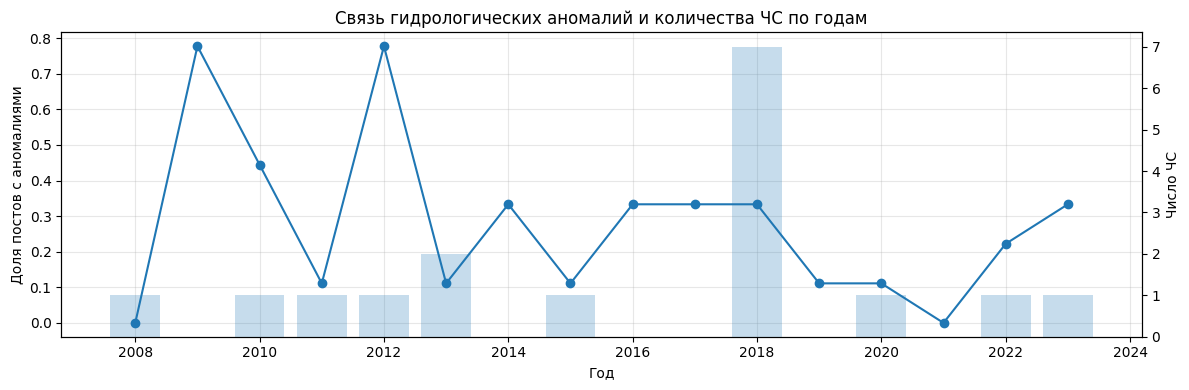

→ data/water_chs_link_by_year.png


In [101]:
if water.empty:
    print('Нет данных уровня воды: загрузите CSV в data/hydro/ или data/water_level_lena.csv')
    df_water_features = pd.DataFrame()
    df_water_peak_lags = pd.DataFrame()
else:
    # (Опционально) Связь гидроаномалий с ЧС по годам, если есть df_mchs
    if 'df_mchs' in globals() and isinstance(df_mchs, pd.DataFrame) and not df_mchs.empty:
        m = df_mchs.copy()

        # Попытка определить колонку даты
        date_col = next((c for c in m.columns if c.lower() in ['date', 'дата']), None)
        if date_col is None:
            cand = [c for c in m.columns if 'дат' in c.lower() or 'date' in c.lower()]
            date_col = cand[0] if cand else None

        if date_col is not None:
            m[date_col] = pd.to_datetime(m[date_col], errors='coerce')
            m = m.dropna(subset=[date_col]).copy()
            m['year'] = m[date_col].dt.year
            m = m[m['year'].between(int(water['year'].min()), int(water['year'].max()))]

            # ЧС по годам
            chs_by_year = m.groupby('year').size().rename('chs_count').reset_index()

            # Гидроэкстремы по годам (доля постов с аномалией)
            hyd = df_water_features.copy()
            hyd['hydro_extreme'] = (
                hyd['spring_peak_cm_z'].abs().ge(1.5)
                | hyd['max_rise_7d_cm_day_z'].abs().ge(1.5)
                | hyd['days_above_p95_z'].abs().ge(1.5)
            )

            yr = (hyd.groupby('year')
                  .agg(posts_total=('post', 'nunique'),
                       hydro_extreme_posts=('hydro_extreme', 'sum'))
                  .reset_index())
            yr['hydro_extreme_share'] = yr['hydro_extreme_posts'] / yr['posts_total']

            link = yr.merge(chs_by_year, on='year', how='left').fillna({'chs_count': 0})
            print('\n=== Связь гидроаномалий и числа ЧС по годам ===')
            print(link.to_string(index=False))

            if link['hydro_extreme_share'].notna().sum() >= 3 and link['chs_count'].notna().sum() >= 3:
                r = link['hydro_extreme_share'].corr(link['chs_count'])
                print(f'Корреляция (hydro_extreme_share vs chs_count): {r:.3f}')

            link.to_csv(RESULTS_DIR / 'water_chs_link_by_year.csv', index=False, encoding='utf-8-sig')
            print('→ результаты/water_chs_link_by_year.csv')

            # Небольшая визуализация связи
            fig, ax1 = plt.subplots(figsize=(12, 4))
            ax1.plot(link['year'], link['hydro_extreme_share'], marker='o', label='Доля постов с гидроаномалиями')
            ax1.set_ylabel('Доля постов с аномалиями')
            ax1.set_xlabel('Год')
            ax1.grid(True, alpha=0.3)

            ax2 = ax1.twinx()
            ax2.bar(link['year'], link['chs_count'], alpha=0.25, label='Число ЧС')
            ax2.set_ylabel('Число ЧС')

            ax1.set_title('Связь гидрологических аномалий и количества ЧС по годам')
            fig.tight_layout()
            plt.savefig(DATA_DIR / 'water_chs_link_by_year.png', dpi=150, bbox_inches='tight')
            plt.show()
            print('→ data/water_chs_link_by_year.png')
        else:
            print('\n[INFO] df_mchs найден, но не удалось определить колонку даты — блок связи с ЧС пропущен.')
    else:
        print('\n[INFO] df_mchs не найден — блок связи с ЧС пропущен.')

In [102]:
# === СВЯЗЬ "СУТОЧНАЯ АНОМАЛИЯ -> ЧС" (НЕ ПО ГОДАМ) ===

# исключаемые станции из анализа аномалий
EXCLUDED_POINTS = ('Верхоянск', 'Оймякон')
EXCL_PAT = '|'.join(re.escape(x.lower()) for x in EXCLUDED_POINTS)

# ----------------------------
# 1) Вспомогательные функции
# ----------------------------
def find_col(df, variants):
    low_map = {c.lower(): c for c in df.columns}
    for v in variants:
        if v.lower() in low_map:
            return low_map[v.lower()]
    for c in df.columns:
        lc = c.lower()
        if any(v.lower() in lc for v in variants):
            return c
    return None

def prep_mchs(df_mchs):
    if df_mchs is None or df_mchs.empty:
        return pd.DataFrame()

    m = df_mchs.copy()
    c_date_start = find_col(m, ['date_start', 'дата_начала', 'дата начала', 'date'])
    c_date_end   = find_col(m, ['date_end', 'дата_окончания', 'дата окончания'])
    c_type       = find_col(m, ['type_chs', 'тип_чс', 'явление'])
    c_loc        = find_col(m, ['location', 'нп', 'населенный пункт', 'населённый пункт'])
    c_dmg        = find_col(m, ['damage_rub', 'ущерб_руб', 'ущерб'])

    if c_date_start is None:
        print('[ERR] В df_mchs не найдена колонка date_start')
        return pd.DataFrame()

    out = pd.DataFrame({
        'date_start': pd.to_datetime(m[c_date_start], errors='coerce'),
        'date_end': pd.to_datetime(m[c_date_end], errors='coerce') if c_date_end else pd.NaT,
        'type_chs': m[c_type].astype(str) if c_type else '',
        'location': m[c_loc].astype(str) if c_loc else '',
        'damage_rub': pd.to_numeric(m[c_dmg], errors='coerce') if c_dmg else np.nan
    }).dropna(subset=['date_start'])

    return out

def prep_anomalies():
    # Приоритет: df_daily_anom из памяти
    if 'df_daily_anom' in globals() and isinstance(df_daily_anom, pd.DataFrame) and not df_daily_anom.empty:
        a = df_daily_anom.copy()
    else:
        # fallback: пробуем файл
        paths = [
            'results/daily_anomalies_operational.csv',
            'результаты/daily_anomalies_operational.csv'
        ]
        loaded = None
        for p in paths:
            try:
                loaded = pd.read_csv(p, encoding='utf-8-sig')
                print(f'[INFO] Загружены суточные аномалии из {p}')
                break
            except Exception:
                pass
        if loaded is None:
            return pd.DataFrame()
        a = loaded

    c_date = find_col(a, ['date', 'anomaly_date', 'дата'])
    if c_date is None:
        print('[ERR] В таблице аномалий не найдена колонка даты')
        return pd.DataFrame()

    a[c_date] = pd.to_datetime(a[c_date], errors='coerce')
    a = a.dropna(subset=[c_date]).copy()

    # нормализуем имя поля даты
    if c_date != 'anomaly_date':
        a = a.rename(columns={c_date: 'anomaly_date'})

    # исключаем станции Верхоянск и Оймякон
    c_station = find_col(a, ['station_name', 'station', 'станция'])
    if c_station:
        before = len(a)
        a = a[~a[c_station].astype(str).str.lower().str.contains(EXCL_PAT, na=False)].copy()
        print(f'[INFO] Исключено по станциям Верхоянск/Оймякон: {before - len(a)} строк')
    else:
        print('[WARN] Колонка станции не найдена — исключить станции напрямую нельзя')

    # убрать дубли одной даты
    a = a.sort_values('anomaly_date').drop_duplicates(subset=['anomaly_date']).reset_index(drop=True)
    return a

def link_event_to_mchs(anomaly_date, mchs, pre_days=3, post_days=30,
                       relevant_types=('паводок', 'половодье', 'затор', 'подтоп', 'наводн'),
                       location_keywords=None):
    if mchs.empty:
        return pd.DataFrame()

    w = mchs.copy()
    lag = (w['date_start'] - anomaly_date).dt.days
    w = w[(lag >= -pre_days) & (lag <= post_days)].copy()
    if w.empty:
        return w

    w['lag_days'] = (w['date_start'] - anomaly_date).dt.days

    if relevant_types:
        pat = '|'.join([str(x).lower() for x in relevant_types])
        w = w[w['type_chs'].str.lower().str.contains(pat, na=False)]

    if location_keywords:
        pat_loc = '|'.join([str(x).lower() for x in location_keywords])
        w = w[w['location'].str.lower().str.contains(pat_loc, na=False)]

    if w.empty:
        return w

    def lag_bin(d):
        ad = abs(int(d))
        if 0 <= ad <= 3: return '0_3'
        if 4 <= ad <= 7: return '4_7'
        if 8 <= ad <= 14: return '8_14'
        if 15 <= ad <= 30: return '15_30'
        return 'out'

    w['lag_bin'] = w['lag_days'].apply(lag_bin)
    w = w[w['lag_bin'] != 'out'].copy()
    w['anomaly_date'] = anomaly_date
    return w

def build_chs_params_string(linked_df):
    """Формирует строку: тип_ЧС / НП / дата_начала_чс / дата_окончания_чс"""
    if linked_df.empty:
        return ''
    tmp = linked_df.copy()
    tmp['date_start_str'] = pd.to_datetime(tmp['date_start'], errors='coerce').dt.strftime('%Y-%m-%d').fillna('')
    tmp['date_end_str'] = pd.to_datetime(tmp['date_end'], errors='coerce').dt.strftime('%Y-%m-%d').fillna('')
    tmp['type_chs'] = tmp['type_chs'].fillna('').astype(str)
    tmp['location'] = tmp['location'].fillna('').astype(str)

    parts = (
        tmp['type_chs'] + ' / ' +
        tmp['location'] + ' / ' +
        tmp['date_start_str'] + ' / ' +
        tmp['date_end_str']
    )
    return ' || '.join(parts.tolist())

# ----------------------------
# 2) Запуск
# ----------------------------
a = prep_anomalies()
m = prep_mchs(df_mchs if 'df_mchs' in globals() else pd.DataFrame())

if a.empty:
    print('[ERR] Нет суточных аномалий. Нужны df_daily_anom или daily_anomalies_operational.csv')
    df_links_detailed = pd.DataFrame()
    df_links_summary = pd.DataFrame()
elif m.empty:
    print('[ERR] Нет валидных данных ЧС (df_mchs)')
    df_links_detailed = pd.DataFrame()
    df_links_summary = pd.DataFrame()
else:
    detailed_rows = []
    summary_rows = []

    # какие поля аномалии хотим видеть в выводе
    anom_info_cols = [c for c in [
        'signals', 'triggered_parameters', 'risk_points', 'severity',
        'tmean', 'precip_mm', 'station_name'
    ] if c in a.columns]

    for _, ar in a.iterrows():
        adate = ar['anomaly_date']
        linked = link_event_to_mchs(
            anomaly_date=adate,
            mchs=m,
            pre_days=3,
            post_days=30,
            relevant_types=('паводок', 'половодье', 'затор', 'подтоп', 'наводн'),
            location_keywords=None
        )

        # пропускаем аномалии без ЧС
        if linked.empty:
            continue

        # детальный вывод (каждая связанная ЧС)
        linked = linked.copy()
        for c in anom_info_cols:
            linked[c] = ar[c]
        detailed_rows.append(linked)

        # сводка по аномалии
        row = {
            'дата_аномалии': adate,
            'год': int(adate.year),
            'n_chs_total': int(len(linked)),
            'sum_damage_0_30': float(linked['damage_rub'].sum(skipna=True)),
            'min_lag_days': linked['lag_days'].min(),
            'max_lag_days': linked['lag_days'].max(),
            'n_chs_0_3': int((linked['lag_bin'] == '0_3').sum()),
            'n_chs_4_7': int((linked['lag_bin'] == '4_7').sum()),
            'n_chs_8_14': int((linked['lag_bin'] == '8_14').sum()),
            'n_chs_15_30': int((linked['lag_bin'] == '15_30').sum()),
            # новая колонка с параметрами ЧС
            'параметры_ЧС (тип_ЧС/НП/дата_начала_чс/дата_окончания_чс)': build_chs_params_string(linked)
        }
        for c in anom_info_cols:
            row[c] = ar[c]
        summary_rows.append(row)

    df_links_detailed = pd.concat(detailed_rows, ignore_index=True) if detailed_rows else pd.DataFrame()
    df_links_summary = pd.DataFrame(summary_rows).sort_values('дата_аномалии').reset_index(drop=True)

print(f'Аномалий всего (после исключения Верхоянск/Оймякон): {len(a)}')
print(f'Аномалий с детектированной ЧС: {len(df_links_summary)}')
display(df_links_summary)

[INFO] Исключено по станциям Верхоянск/Оймякон: 1018 строк
Аномалий всего (после исключения Верхоянск/Оймякон): 1621
Аномалий с детектированной ЧС: 99


,дата_аномалии,год,n_chs_total,sum_damage_0_30,min_lag_days,max_lag_days,n_chs_0_3,n_chs_4_7,n_chs_8_14,n_chs_15_30,параметры_ЧС (тип_ЧС/НП/дата_начала_чс/дата_окончания_чс),signals,triggered_parameters,risk_points,severity,tmean,precip_mm,station_name
0,2008-05-01,2008,1,0.0,23,23,0,0,0,1,Половодье / (р. Лена) / 2008-05-24 / 2008-05-25,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,-5.5,8.1,Жиганск
1,2008-05-18,2008,1,0.0,6,6,0,1,0,0,Половодье / (р. Лена) / 2008-05-24 / 2008-05-25,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,экстремальная,-1.7,16.6,Жиганск
2,2008-05-26,2008,1,0.0,-2,-2,1,0,0,0,Половодье / (р. Лена) / 2008-05-24 / 2008-05-25,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,экстремальная,5.2,18.4,Киренск
3,2010-04-23,2010,1,0.0,27,27,0,0,0,1,Затор / (р. Лена) / 2010-05-20 / 2010-05-22,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,2.2,3.9,Жиганск
4,2010-04-26,2010,1,0.0,24,24,0,0,0,1,Затор / (р. Лена) / 2010-05-20 / 2010-05-22,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,-5.7,6.4,Олёкминск
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,2022-05-25,2022,1,0.0,-2,-2,1,0,0,0,"Половодье / (р. Лена, г.п. Графский берег / 20...",экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,3.0,4.9,Жиганск
95,2023-05-07,2023,1,0.0,14,14,0,0,1,0,"Половодье / (р. Лена, ГП Сангар). / 2023-05-2...",экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,5.0,5.0,Киренск
96,2023-05-10,2023,1,0.0,11,11,0,0,1,0,"Половодье / (р. Лена, ГП Сангар). / 2023-05-2...",резкое потепление за сутки,delta_tmean_1d ≥ 8°C,1,умеренная,11.9,0.0,Олёкминск
97,2023-05-13,2023,1,0.0,8,8,0,0,1,0,"Половодье / (р. Лена, ГП Сангар). / 2023-05-2...",экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,5.8,5.2,Киренск


In [103]:
# === ОБРАТНАЯ СВЯЗЬ: "КАЖДОЕ ЧС -> ВСЕ СООТВЕТСТВУЮЩИЕ АНОМАЛИИ" ===
# (signals гарантированно выводится и в detailed, и в summary/anomalies_list)


if 'df_links_detailed' not in globals() or df_links_detailed.empty:
    print('[ERR] df_links_detailed пустой. Сначала запусти предыдущую ячейку.')
    df_chs_to_anomaly_all = pd.DataFrame()
    df_chs_to_anomaly_summary = pd.DataFrame()
else:
    x = df_links_detailed.copy()

    # Нормализация дат
    for c in ['date_start', 'date_end', 'anomaly_date']:
        if c in x.columns:
            x[c] = pd.to_datetime(x[c], errors='coerce')

    # Гарантируем наличие signals
    if 'signals' not in x.columns:
        x['signals'] = np.nan
    for alt in ['signal', 'signals_text', 'risk_signal']:
        if alt in x.columns:
            x['signals'] = x['signals'].fillna(x[alt])
    if 'triggered_parameters' in x.columns:
        x['signals'] = x['signals'].fillna(x['triggered_parameters'])
    x['signals'] = x['signals'].astype(str).replace({'nan': '', 'None': ''}).str.strip()

    # ID ЧС
    chs_id_cols = [c for c in ['date_start', 'date_end', 'type_chs', 'location'] if c in x.columns]
    x['chs_id'] = x[chs_id_cols].astype(str).agg(' | '.join, axis=1)

    # -------- 1) Детальная таблица: все связки ЧС -> аномалии --------
    cols_out = [c for c in [
        'chs_id', 'type_chs', 'location', 'date_start', 'date_end',
        'anomaly_date', 'lag_days', 'lag_bin',
        'station_name', 'signals', 'triggered_parameters',
        'risk_points', 'severity', 'tmean', 'precip_mm'
    ] if c in x.columns]

    df_chs_to_anomaly_all = (
        x[cols_out]
        .sort_values(['date_start', 'type_chs', 'location', 'anomaly_date'], na_position='last')
        .reset_index(drop=True)
    )

    # -------- 2) Сводная таблица: 1 строка на ЧС + список всех аномалий --------
    tmp = df_chs_to_anomaly_all.copy()
    tmp['anomaly_date'] = pd.to_datetime(tmp['anomaly_date'], errors='coerce')

    def fmt_anom_row(r):
        ad_str = r['anomaly_date'].strftime('%Y-%m-%d') if pd.notna(r['anomaly_date']) else ''
        sig = str(r.get('signals', '')).strip()
        return (
            f"{ad_str} | "
            f"lag={r.get('lag_days', '')} | "
            f"станция={r.get('station_name', '')} | "
            f"signals={sig if sig else '-'} | "
            f"trg={r.get('triggered_parameters', '')} | "
            f"sev={r.get('severity', '')}"
        )

    tmp['anomaly_str'] = tmp.apply(fmt_anom_row, axis=1)

    grp_cols = [c for c in ['chs_id', 'type_chs', 'location', 'date_start', 'date_end'] if c in tmp.columns]

    df_chs_to_anomaly_summary = (
        tmp.groupby(grp_cols, dropna=False, as_index=False)
           .agg(
               n_anomalies=('anomaly_date', 'count'),
               signals_list=('signals', lambda s: ' | '.join(sorted(set(v for v in s.astype(str) if v.strip() and v != 'nan')))),
               anomalies_list=('anomaly_str', lambda s: ' || '.join(s.astype(str)))
           )
           .sort_values(['date_start', 'type_chs', 'location'], na_position='last')
           .reset_index(drop=True)
    )

    print(f'Всего связок ЧС->аномалия: {len(df_chs_to_anomaly_all)}')
    print(f'Уникальных ЧС: {df_chs_to_anomaly_summary["chs_id"].nunique()}')

    print('\n[ДЕТАЛЬНО] Все аномалии для каждого ЧС:')
    display(df_chs_to_anomaly_all)

    print('\n[СВОДНО] 1 строка на ЧС + список всех аномалий:')
    display(df_chs_to_anomaly_summary)

Всего связок ЧС->аномалия: 167
Уникальных ЧС: 17

[ДЕТАЛЬНО] Все аномалии для каждого ЧС:


,chs_id,type_chs,location,date_start,date_end,anomaly_date,lag_days,lag_bin,station_name,signals,triggered_parameters,risk_points,severity,tmean,precip_mm
0,2008-05-24 | 2008-05-25 | Половодье | (р. Лена),Половодье,(р. Лена),2008-05-24,2008-05-25,2008-05-01,23,15_30,Жиганск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,-5.5,8.1
1,2008-05-24 | 2008-05-25 | Половодье | (р. Лена),Половодье,(р. Лена),2008-05-24,2008-05-25,2008-05-18,6,4_7,Жиганск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,экстремальная,-1.7,16.6
2,2008-05-24 | 2008-05-25 | Половодье | (р. Лена),Половодье,(р. Лена),2008-05-24,2008-05-25,2008-05-26,-2,0_3,Киренск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,экстремальная,5.2,18.4
3,2010-05-20 | 2010-05-22 | Затор | (р. Лена),Затор,(р. Лена),2010-05-20,2010-05-22,2010-04-23,27,15_30,Жиганск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,2.2,3.9
4,2010-05-20 | 2010-05-22 | Затор | (р. Лена),Затор,(р. Лена),2010-05-20,2010-05-22,2010-04-26,24,15_30,Олёкминск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,-5.7,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,2022-05-23 | 2022-05-24 | Половодье | (р. Лена...,Половодье,"(р. Лена, г.п. Графский берег",2022-05-23,2022-05-24,2022-05-25,-2,0_3,Жиганск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,3.0,4.9
163,2023-05-21 | 2023-05-23 | Половодье | (р. Лена...,Половодье,"(р. Лена, ГП Сангар).",2023-05-21,2023-05-23,2023-05-07,14,8_14,Киренск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,5.0,5.0
164,2023-05-21 | 2023-05-23 | Половодье | (р. Лена...,Половодье,"(р. Лена, ГП Сангар).",2023-05-21,2023-05-23,2023-05-10,11,8_14,Олёкминск,резкое потепление за сутки,delta_tmean_1d ≥ 8°C,1,умеренная,11.9,0.0
165,2023-05-21 | 2023-05-23 | Половодье | (р. Лена...,Половодье,"(р. Лена, ГП Сангар).",2023-05-21,2023-05-23,2023-05-13,8,8_14,Киренск,экстремальные суточные осадки,precip_mm ≥ precip_p95,2,умеренная,5.8,5.2



[СВОДНО] 1 строка на ЧС + список всех аномалий:


,chs_id,type_chs,location,date_start,date_end,n_anomalies,signals_list,anomalies_list
0,2008-05-24 | 2008-05-25 | Половодье | (р. Лена),Половодье,(р. Лена),2008-05-24,2008-05-25,3,экстремальные суточные осадки,2008-05-01 | lag=23 | станция=Жиганск | signal...
1,2010-05-20 | 2010-05-22 | Затор | (р. Лена),Затор,(р. Лена),2010-05-20,2010-05-22,11,аномально тёплый день | экстремальные суточные...,2010-04-23 | lag=27 | станция=Жиганск | signal...
2,2011-05-16 | 2011-05-17 | Затор | (р. Лена),Затор,(р. Лена),2011-05-16,2011-05-17,12,аномально тёплый день | аномально тёплый день;...,2011-04-18 | lag=28 | станция=Киренск | signal...
3,2012-05-14 | 2012-05-16 | Половодье | (Олекмин...,Половодье,(Олекминский район),2012-05-14,2012-05-16,13,аномально тёплый день | экстремальные суточные...,2012-04-16 | lag=28 | станция=Киренск | signal...
4,"2013-05-10 | 2013-05-19 | Затор | (реки Лена, ...",Затор,"(реки Лена, Колыма, Амга)",2013-05-10,2013-05-19,10,резкое потепление за сутки | экстремальные сут...,2013-04-10 | lag=30 | станция=Жиганск | signal...
5,2013-05-10 | 2013-05-19 | Половодье | (реки Ле...,Половодье,"(реки Лена, Колыма, Амга)",2013-05-10,2013-05-19,10,резкое потепление за сутки | экстремальные сут...,2013-04-10 | lag=30 | станция=Жиганск | signal...
6,2015-05-13 | 2015-05-13 | Затор | (р. Лена п. ...,Затор,(р. Лена п. Табага),2015-05-13,2015-05-13,10,аномально тёплый день | экстремальные суточные...,2015-04-16 | lag=27 | станция=Якутск | signals...
7,2018-05-07 | 2018-05-07 | Затор | nan,Затор,nan,2018-05-07,2018-05-07,10,аномально тёплый день | зимняя/весенняя оттепе...,2018-04-14 | lag=23 | станция=Киренск | signal...
8,2018-05-07 | 2018-07-01 | Половодье | nan,Половодье,nan,2018-05-07,2018-07-01,10,аномально тёплый день | зимняя/весенняя оттепе...,2018-04-14 | lag=23 | станция=Киренск | signal...
9,2018-05-14 | 2018-05-18 | Затор | (сТабага - р...,Затор,(сТабага - р.Лена),2018-05-14,2018-05-18,11,аномально тёплый день | зимняя/весенняя оттепе...,2018-04-14 | lag=30 | станция=Киренск | signal...


In [104]:
df_chs_to_anomaly_summary.anomalies_list[0]

'2008-05-01 | lag=23 | станция=Жиганск | signals=экстремальные суточные осадки | trg=precip_mm ≥ precip_p95 | sev=умеренная || 2008-05-18 | lag=6 | станция=Жиганск | signals=экстремальные суточные осадки | trg=precip_mm ≥ precip_p95 | sev=экстремальная || 2008-05-26 | lag=-2 | станция=Киренск | signals=экстремальные суточные осадки | trg=precip_mm ≥ precip_p95 | sev=экстремальная'

In [105]:
# === ЭКСПОРТ В EXCEL (в папку RESULTS_DIR) ===

# Проверки
if 'RESULTS_DIR' not in globals():
    raise NameError("Переменная RESULTS_DIR не найдена. Задай её, например: RESULTS_DIR = Path('results')")

if 'df_chs_to_anomaly_all' not in globals():
    raise NameError("df_chs_to_anomaly_all не найден. Сначала запусти ячейку с формированием таблиц.")

if 'df_chs_to_anomaly_summary' not in globals():
    raise NameError("df_chs_to_anomaly_summary не найден. Сначала запусти ячейку с формированием таблиц.")

# Папка назначения
out_dir = Path(RESULTS_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

# Имя файла
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out_file = out_dir / f'chs_to_anomalies_{ts}.xlsx'

# Экспорт на 2 листа
with pd.ExcelWriter(out_file, engine='openpyxl') as writer:
    df_chs_to_anomaly_all.to_excel(writer, sheet_name='all_links', index=False)
    df_chs_to_anomaly_summary.to_excel(writer, sheet_name='summary_by_chs', index=False)

print(f'[OK] Файл сохранён: {out_file}')

ModuleNotFoundError: No module named 'openpyxl'

## 14. Сценарный анализ

Классификация лет по сценариям реагирования.

In [ ]:
RESPONSE_MEASURES = {
    'Базовый': [
        'Плановый мониторинг температуры грунта (ежеквартально)',
        'Проверка состояния фундаментов зданий',
    ],
    'Умеренный': [
        'Усиленный мониторинг (ежемесячно)',
        'Оповещение ответственных лиц о повышенном риске',
        'Инспекция инженерной инфраструктуры',
        'Готовность к развёртыванию аварийных бригад',
    ],
    'Высокий': [
        'Предупреждение населения о риске наводнения/подтопления',
        'Приведение сил МЧС в готовность',
        'Эвакуационный план для зон риска',
        'Круглосуточный мониторинг уровня воды на гидропостах',
        'Проверка дамб и водозащитных сооружений',
    ],
    'Критический': [
        'Немедленное оповещение ГО и ЧС',
        'Превентивная эвакуация населения из зон риска',
        'Развёртывание аварийных и спасательных бригад',
        'Запрос дополнительных ресурсов (федеральный уровень)',
        'Введение режима ЧС муниципального/регионального уровня',
        'Мониторинг состояния жилого фонда и инфраструктуры',
    ]
}

def classify_scenario(n_moderate: int, n_extreme: int, alt_z: float = 0.0) -> str:
    # alt_z ≥ 3 — экстремальное протаивание, повышает категорию
    if n_extreme >= 3 or (n_extreme >= 2 and abs(alt_z) >= 3):
        return 'Критический'
    elif n_moderate >= 2 and n_extreme >= 1:
        return 'Высокий'
    elif n_moderate >= 1:
        return 'Умеренный'
    return 'Базовый'


if not df_anom.empty:
    # ALT_z: берём из df_anom (0.0 если CALM не загружен)
    alt_z_col = df_anom['ALT_z'] if 'ALT_z' in df_anom.columns else pd.Series(0.0, index=df_anom.index)

    df_anom['сценарий'] = [
        classify_scenario(
            int(row['n_moderate']),
            int(row['n_extreme']),
            float(alt_z_col.get(yr, 0.0) or 0.0)
        )
        for yr, row in df_anom.iterrows()
    ]
    df_anom['меры_реагирования'] = df_anom['сценарий'].map(
        lambda s: '; '.join(RESPONSE_MEASURES[s])
    )

    print('Распределение сценариев:')
    print(df_anom['сценарий'].value_counts())
    print()
    cols = ['TDD_z', 'FDD_z', 'n_moderate', 'n_extreme']
    if 'ALT_z' in df_anom.columns:
        cols.insert(2, 'ALT_z')
    cols.append('сценарий')
    print(df_anom[[c for c in cols if c in df_anom.columns]].dropna(how='all').tail(20))
else:
    print('Нет данных для классификации сценариев')


Распределение сценариев:
сценарий
Базовый      6
Умеренный    5
Высокий      5
Name: count, dtype: int64

      TDD_z  FDD_z  n_moderate  n_extreme   сценарий
year                                                
2008   0.46  -0.21           0          0    Базовый
2009   0.72  -1.03           0          0    Базовый
2010  -0.06  -0.33           0          0    Базовый
2011   0.37  -0.15           1          1  Умеренный
2012   0.69  -1.21           0          0    Базовый
2013  -0.51  -0.01           2          2    Высокий
2014  -0.06  -0.91           0          0    Базовый
2015  -1.46   1.97           2          2    Высокий
2016  -2.42  -0.08           1          1  Умеренный
2017   0.06   0.93           1          1  Умеренный
2018  -0.03   0.17           0          0    Базовый
2019   0.02   0.44           1          1  Умеренный
2020   1.03   2.13           2          1    Высокий
2021   1.99  -1.12           3          2    Высокий
2022  -0.20   0.20           2          2    В

## 15. Визуализация

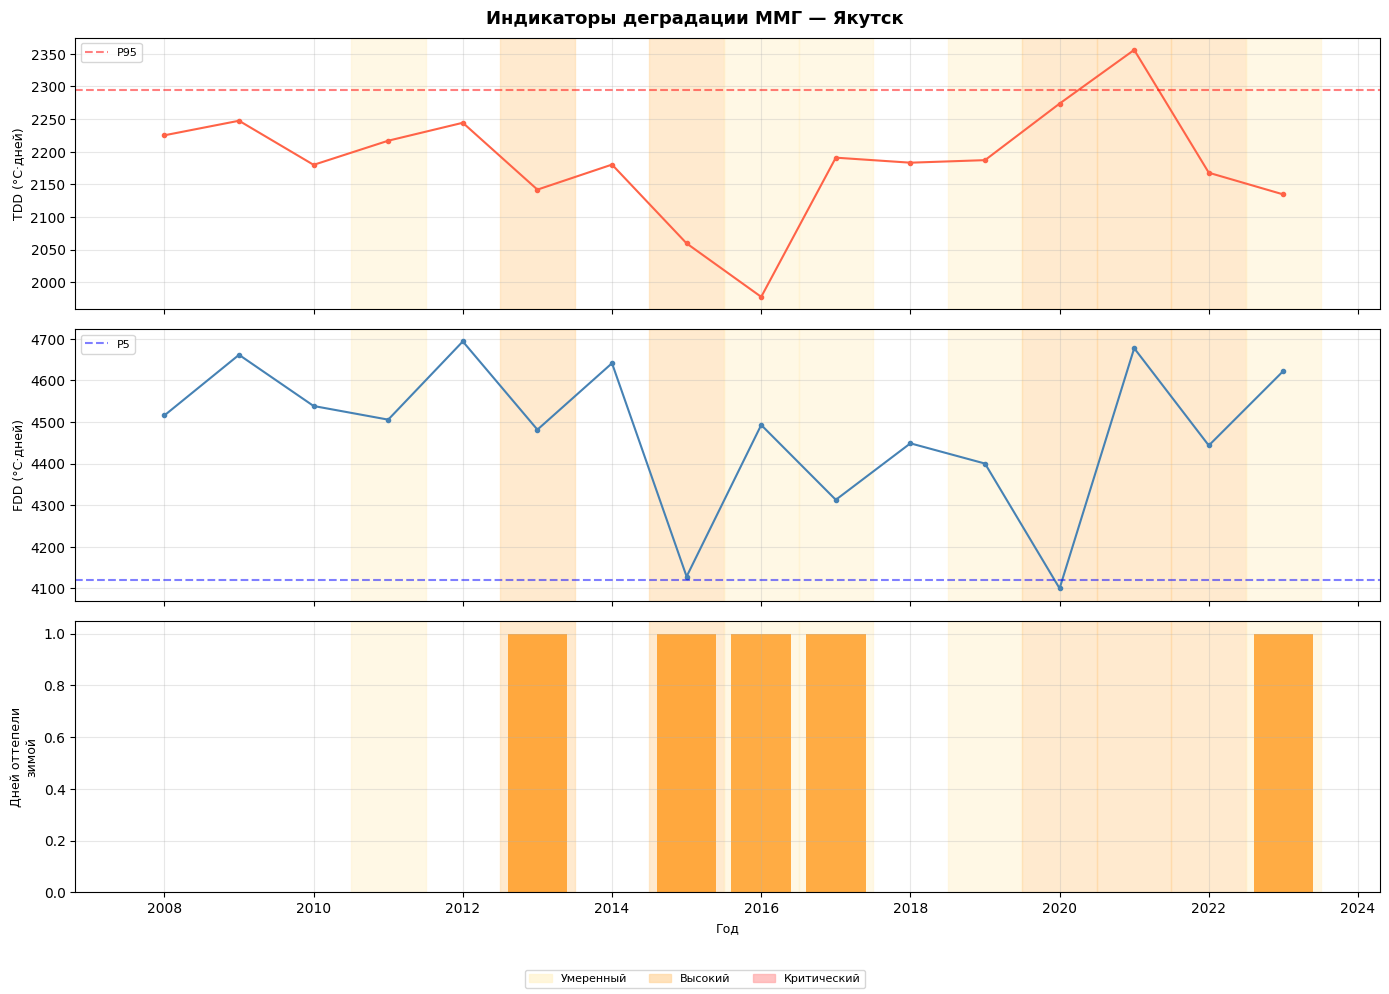

→ data/anomalies_overview.png


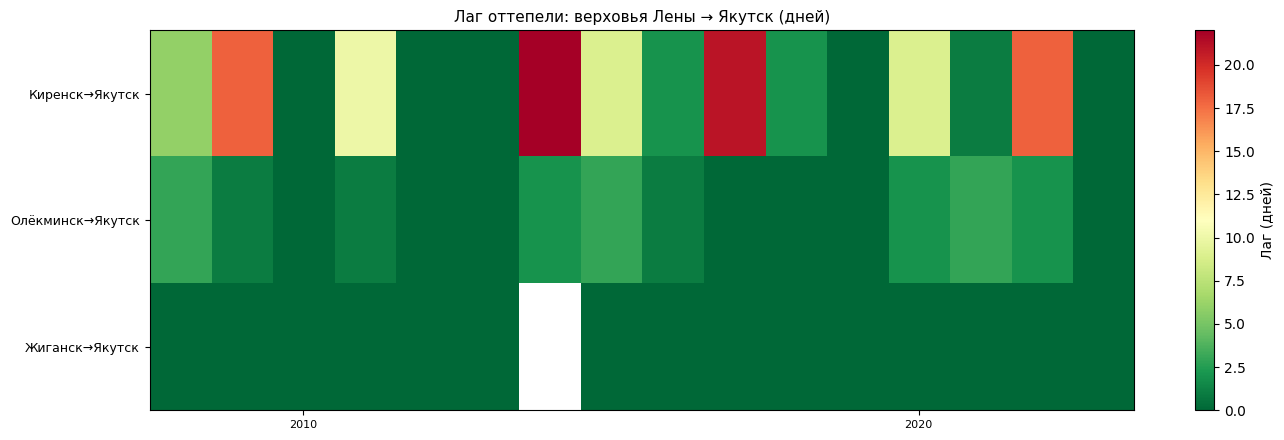

→ data/lena_lag.png


In [ ]:
scenario_colors = {
    'Базовый': 'white', 'Умеренный': '#fff3cd',
    'Высокий': '#ffd7a0', 'Критический': '#ffaaaa'
}

# ── Рис. 1: обзор TDD / FDD / дни оттепели (Якутск) ─────────────────────
if not df_dd.empty and not df_anom.empty:
    years = df_dd['year'].values

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle('Индикаторы деградации ММГ — Якутск', fontsize=13, fontweight='bold')

    axes[0].plot(years, df_dd['TDD'].values, 'o-', color='tomato', lw=1.5, ms=3)
    axes[0].axhline(df_dd['TDD'].quantile(0.95), ls='--', color='red', alpha=0.5, label='P95')
    axes[0].set_ylabel('TDD (°С·дней)', fontsize=9)
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].plot(years, df_dd['FDD'].values, 'o-', color='steelblue', lw=1.5, ms=3)
    axes[1].axhline(df_dd['FDD'].quantile(0.05), ls='--', color='blue', alpha=0.5, label='P5')
    axes[1].set_ylabel('FDD (°С·дней)', fontsize=9)
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    axes[2].bar(years, df_dd['winter_thaw_days'].values, color='darkorange', alpha=0.7)
    axes[2].set_ylabel('Дней оттепели\nзимой', fontsize=9)
    axes[2].set_xlabel('Год', fontsize=9)
    axes[2].grid(True, alpha=0.3)

    if 'сценарий' in df_anom.columns:
        for year in df_anom.index:
            color = scenario_colors.get(df_anom.loc[year, 'сценарий'], 'white')
            if color != 'white':
                for ax in axes:
                    ax.axvspan(year - 0.5, year + 0.5, color=color, alpha=0.5, zorder=0)

    patches = [mpatches.Patch(color=v, alpha=0.7, label=k)
               for k, v in scenario_colors.items() if v != 'white']
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=8)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(DATA_DIR / 'anomalies_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('→ data/anomalies_overview.png')
else:
    print('Нет данных для рис. 1 (TDD/FDD Якутск)')

# ── Рис. 2: тепловая карта лагов оттепели вдоль профиля Лены ─────────────
if not lag_df.empty:
    lag_cols = [c for c in lag_df.columns if c.startswith('лаг')]
    if lag_cols:
        plot_data = lag_df[lag_cols].dropna(how='all')
        plot_data = plot_data[plot_data.index >= 1960]

        fig2, ax = plt.subplots(figsize=(14, max(2.5, len(lag_cols) * 1.5)))
        mat = plot_data.T.values.astype(float)
        vmax = float(np.nanmax(mat)) if np.any(~np.isnan(mat)) else 30
        im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=vmax)

        ax.set_yticks(range(len(lag_cols)))
        ax.set_yticklabels([c.replace('лаг ', '') for c in lag_cols], fontsize=9)

        x_years = plot_data.index.tolist()
        tick_pos  = [i for i, y in enumerate(x_years) if y % 10 == 0]
        tick_labs = [str(x_years[i]) for i in tick_pos]
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labs, fontsize=8)

        plt.colorbar(im, ax=ax, label='Лаг (дней)')
        ax.set_title('Лаг оттепели: верховья Лены → Якутск (дней)', fontsize=11)
        plt.tight_layout()
        plt.savefig(DATA_DIR / 'lena_lag.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('→ data/lena_lag.png')
else:
    print('Нет данных для рис. 2 — загрузите Киренск/Олёкминск в data/air/')


## 16. Итоговый экспорт

In [ ]:
if not df_anom.empty and 'сценарий' in df_anom.columns:
    export_cols = ['TDD', 'TDD_z', 'FDD', 'FDD_z',
                   'thaw_d', 'n_moderate', 'n_extreme',
                   'сценарий', 'меры_реагирования']
    avail = [c for c in export_cols if c in df_anom.columns]
    df_anom[avail].to_csv(RESULTS_DIR / 'scenario_annual.csv', encoding='utf-8-sig')
    print('→ результаты/scenario_annual.csv')

if 'df_result' in dir() and not df_result.empty:
    df_result.to_csv(RESULTS_DIR / 'anomaly_chs_linked.csv',
                     index=False, encoding='utf-8-sig')
    print('→ результаты/anomaly_chs_linked.csv')

if not lag_df.empty:
    lag_df[[c for c in lag_df.columns if c.startswith('лаг')]].to_csv(
        RESULTS_DIR / 'lena_lag.csv', encoding='utf-8-sig')
    print('→ результаты/lena_lag.csv')

# ── Статус загрузки данных ────────────────────────────────────────────────
print('\n=== Статус данных ===')
loaded_sids = set(df_air['station_id'].unique()) if not df_air.empty else set()
for sid in LENA_PROFILE:
    name   = YAKUTIA_STATIONS[sid]
    status = '✓' if sid in loaded_sids else '✗  нужно скачать'
    print(f'  WMO {sid}  {name}: {status}')

loaded_posts = set(df_water['post'].unique()) if not df_water.empty else set()
for name in HYDRO_POSTS:
    status = '✓' if name in loaded_posts else '✗  нужно скачать'
    print(f'  Гидропост {name}: {status}')



→ результаты/scenario_annual.csv
→ результаты/anomaly_chs_linked.csv
→ результаты/lena_lag.csv

=== Статус данных ===
  WMO 30230  Киренск: ✓
  WMO 24944  Олёкминск: ✓
  WMO 24959  Якутск: ✓
  WMO 24343  Жиганск: ✓
  Гидропост Киренск: ✓
  Гидропост Витим: ✓
  Гидропост Ленск: ✓
  Гидропост Олёкминск: ✓
  Гидропост Покровск: ✓
  Гидропост Якутск: ✓
  Гидропост Табага: ✓
  Гидропост Сангар: ✓
  Гидропост Жиганск: ✓
